In [1]:
# Add project folder to sys.path
import sys
from pathlib import Path
project_path = Path(r"C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor")
sys.path.append(str(project_path))

### Imports

In [2]:
from data_exploration.utils.data_loader import DataLoader
from data_exploration.utils.data_explorer import DataExplorer
from second_term_gpa_regression.utils.data_cleaner import DataCleaner
from skimpy import skim
import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import keras
import tensorflow as tf
from keras_tuner import Hyperband
import shutil
import time

from tensorflow.keras.optimizers import Adam, SGD, RMSprop


sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110})

In [3]:
# # Load the original student dataset 
# data_file = project_path / "data/Student data.csv"
# dl = DataLoader(str(data_file))
# structure_df = dl.load_and_clean_data()
# structure_df.columns.to_list()

#  # Save the cleaned dataset structure to a new CSV file
# structure_df.to_csv(project_path / "data/structured_student_data.csv", index=False)

In [4]:
# ------ Helper Classes for Custom Metrics ------
class RMSEMetric(tf.keras.metrics.Metric):
    """Dataset-level RMSE accumulated across batches."""

    def __init__(self, name="rmse", **kwargs):
        super().__init__(name=name, **kwargs)
        self.sse = self.add_weight(name="sse", initializer="zeros")
        self.count = self.add_weight(name="count", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.reshape(tf.cast(y_true, self.dtype), [-1])
        y_pred = tf.reshape(tf.cast(y_pred, self.dtype), [-1])

        squared_errors = tf.square(y_true - y_pred)
        self.sse.assign_add(tf.reduce_sum(squared_errors))
        self.count.assign_add(tf.cast(tf.size(y_true), self.dtype))

    def result(self):
        return tf.sqrt(tf.math.divide_no_nan(self.sse, self.count))

    def reset_state(self):
        for variable in self.variables:
            variable.assign(0.0)

class R2Metric(tf.keras.metrics.Metric):
    """Dataset-level R-squared metric accumulated across batches."""

    def __init__(self, name="r2", **kwargs):
        super().__init__(name=name, **kwargs)
        self.ss_res = self.add_weight(name="ss_res", initializer="zeros")
        self.sum_y = self.add_weight(name="sum_y", initializer="zeros")
        self.sum_y_sq = self.add_weight(name="sum_y_sq", initializer="zeros")
        self.count = self.add_weight(name="count", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.reshape(tf.cast(y_true, self.dtype), [-1])
        y_pred = tf.reshape(tf.cast(y_pred, self.dtype), [-1])

        self.ss_res.assign_add(tf.reduce_sum(tf.square(y_true - y_pred)))
        self.sum_y.assign_add(tf.reduce_sum(y_true))
        self.sum_y_sq.assign_add(tf.reduce_sum(tf.square(y_true)))
        self.count.assign_add(tf.cast(tf.size(y_true), self.dtype))

    def result(self):
        ss_tot = self.sum_y_sq - tf.square(self.sum_y) / (self.count + tf.keras.backend.epsilon())
        return 1.0 - tf.math.divide_no_nan(self.ss_res, ss_tot + tf.keras.backend.epsilon())

    def reset_state(self):
        for variable in self.variables:
            variable.assign(0.0)

In [5]:
# ----- Helper Functions -----
def print_header(name):
    """Print a compact section header."""
    print("\n" + f" {name} ".center(72, "=") + "\n")


def custom_callback(monitor, mode, patience, filepath):
    """Early stopping and model checkpoint callbacks for training."""
    es = EarlyStopping(monitor=monitor, patience=patience, restore_best_weights=True, verbose=1, mode=mode)
    mc = ModelCheckpoint(filepath=filepath, monitor=monitor, verbose=1, save_best_only=True, mode=mode)
    return es, mc


def get_target_scale(scaler_obj=None):
    scaler_obj = scaler_obj or globals().get('scaler', None)
    if scaler_obj is None or not hasattr(scaler_obj, 'data_min_') or not hasattr(scaler_obj, 'data_max_'):
        return 1.0
    return float(np.asarray(scaler_obj.data_max_ - scaler_obj.data_min_).ravel()[0])


def plot_regression_history(history, title_prefix='Model', scaler_obj=None):
    target_scale = get_target_scale(scaler_obj)
    mse_scale = target_scale ** 2

    train_mae = np.asarray(history.history['mae']) * target_scale
    val_mae = np.asarray(history.history['val_mae']) * target_scale
    train_loss = np.asarray(history.history['loss']) * mse_scale
    val_loss = np.asarray(history.history['val_loss']) * mse_scale

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(train_mae, label='Train MAE')
    axes[0].plot(val_mae, label='Val MAE')
    axes[0].set(title=f'{title_prefix} MAE', xlabel='Epoch', ylabel='MAE (GPA)')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(train_loss, label='Train Loss')
    axes[1].plot(val_loss, label='Val Loss')
    if 'rmse' in history.history:
        axes[1].plot(np.asarray(history.history['rmse']) * target_scale, '--', label='Train RMSE')
        axes[1].plot(np.asarray(history.history['val_rmse']) * target_scale, '--', label='Val RMSE')
    axes[1].set(title=f'{title_prefix} Loss & RMSE', xlabel='Epoch', ylabel='Value (GPA / GPA²)')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    if 'r2' in history.history:
        axes[2].plot(history.history['r2'], label='Train R² (Scaled y)')
        axes[2].plot(history.history['val_r2'], label='Val R² (Scaled y)')
        axes[2].set(title=f'{title_prefix} R² (Scaled y)', xlabel='Epoch', ylabel='R²')
        axes[2].legend(); axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    best = int(np.argmin(history.history['val_loss']))
    get = lambda values: f"{np.asarray(values)[best]:.4f}"

    print(f"\nBest Epoch: {best + 1}")
    print('-' * 40)
    print(f"MAE (GPA)   -> Train: {get(train_mae)} | Val: {get(val_mae)}")
    if 'rmse' in history.history:
        print(f"RMSE (GPA)  -> Train: {get(np.asarray(history.history['rmse']) * target_scale)} | Val: {get(np.asarray(history.history['val_rmse']) * target_scale)}")
    print(f"Loss (GPA²) -> Train: {get(train_loss)} | Val: {get(val_loss)}")
    if 'r2' in history.history:
        print(f"R² (Scaled y) -> Train: {get(history.history['r2'])} | Val: {get(history.history['val_r2'])}")


def get_optimizer(name, learning_rate):
    if name == 'adam':
        return Adam(learning_rate=learning_rate)
    if name == 'sgd':
        return SGD(learning_rate=learning_rate, momentum=0.9)
    if name == 'rmsprop':
        return RMSprop(learning_rate=learning_rate)
    raise ValueError(f'Unsupported optimizer: {name}')


def build_dense_model(input_dim, layer_specs):
    model = keras.Sequential([keras.layers.Input(shape=(input_dim,))])
    for spec in layer_specs:
        model.add(Dense(spec['units'], activation=spec['activation']))
        if spec.get('batch_norm', False):
            model.add(BatchNormalization())
        if spec.get('dropout', 0.0) > 0:
            model.add(Dropout(spec['dropout']))
    model.add(Dense(1))
    return model


def compile_regression_model(model, optimizer_name, learning_rate):
    model.compile(
        optimizer=get_optimizer(optimizer_name, learning_rate),
        loss='mse',
        metrics=['mae', RMSEMetric(name='rmse'), R2Metric(name='r2')]
    )
    return model


def inverse_transform_target(values, scaler):
    return scaler.inverse_transform(np.asarray(values).reshape(-1, 1)).flatten()


def evaluate_model_original_scale(model, X_split, y_split, scaler, split_name='Split', verbose=0, print_summary=True):
    y_pred_scaled = model.predict(X_split, verbose=verbose).ravel()
    y_true_scaled = np.asarray(y_split).ravel()
    y_true_actual = inverse_transform_target(y_split, scaler)
    y_pred_actual = inverse_transform_target(y_pred_scaled, scaler)
    r2_original = float(r2_score(y_true_actual, y_pred_actual))
    r2_scaled = float(r2_score(y_true_scaled, y_pred_scaled))

    metrics = {
        'split': split_name,
        'rmse': float(mean_squared_error(y_true_actual, y_pred_actual) ** 0.5),
        'mse': float(mean_squared_error(y_true_actual, y_pred_actual)),
        'mae': float(mean_absolute_error(y_true_actual, y_pred_actual)),
        'r2_original': r2_original,
        'r2_scaled': r2_scaled,
    }

    if print_summary:
        print(f"{split_name} RMSE: {metrics['rmse']:.4f}")
        print(f"{split_name} MSE:  {metrics['mse']:.4f}")
        print(f"{split_name} MAE:              {metrics['mae']:.4f}")
        print(f"{split_name} R² (Original GPA): {metrics['r2_original']:.4f}")
        print(f"{split_name} R² (Scaled y):     {metrics['r2_scaled']:.4f}")

    prediction_df = pd.DataFrame({
        'Actual GPA': y_true_actual,
        'Predicted GPA': y_pred_actual,
    })
    prediction_df['Residual'] = prediction_df['Actual GPA'] - prediction_df['Predicted GPA']
    prediction_df['Absolute Error'] = prediction_df['Residual'].abs()
    prediction_df['Squared Error'] = prediction_df['Residual'] ** 2
    prediction_df = prediction_df.sort_values('Absolute Error', ascending=False).reset_index(drop=True)

    return metrics, prediction_df


def format_metrics_display(df):
    return df.rename(columns={
        'rmse': 'RMSE (GPA)',
        'mse': 'MSE (GPA²)',
        'mae': 'MAE (GPA)',
        'r2_original': 'R² (Original GPA)',
        'r2_scaled': 'R² (Scaled y)',
    })


def format_local_search_display(df):
    return df.rename(columns={
        'trial': 'Trial',
        'trial_name': 'Trial Name',
        'optimizer': 'Optimizer',
        'learning_rate': 'Learning Rate',
        'batch_size': 'Batch Size',
        'best_epoch': 'Best Epoch',
        'val_rmse': 'Val RMSE (GPA)',
        'val_mae': 'Val MAE (GPA)',
        'val_r2_original': 'Val R² (Original GPA)',
        'val_r2_scaled': 'Val R² (Scaled y)',
        'test_rmse': 'Test RMSE (GPA)',
        'test_mae': 'Test MAE (GPA)',
        'test_r2_original': 'Test R² (Original GPA)',
        'test_r2_scaled': 'Test R² (Scaled y)',
        'architecture': 'Architecture',
    })


def plot_prediction_diagnostics(prediction_df, title_prefix='Model'):
    actual = prediction_df['Actual GPA']
    predicted = prediction_df['Predicted GPA']
    residuals = prediction_df['Residual']
    plot_min = min(actual.min(), predicted.min())
    plot_max = max(actual.max(), predicted.max())

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.scatterplot(x=actual, y=predicted, color='#4c78a8', alpha=0.65, ax=axes[0])
    axes[0].plot([plot_min, plot_max], [plot_min, plot_max], 'r--', linewidth=1.5)
    axes[0].set_title(f'{title_prefix}: Actual vs Predicted')
    axes[0].set_xlabel('Actual GPA')
    axes[0].set_ylabel('Predicted GPA')
    axes[0].set_xlim(plot_min, plot_max)
    axes[0].set_ylim(plot_min, plot_max)
    axes[0].grid(True, alpha=0.3)

    sns.scatterplot(x=predicted, y=residuals, color='#f58518', alpha=0.65, ax=axes[1])
    axes[1].axhline(0, color='red', linestyle='--', linewidth=1.2)
    axes[1].set_title(f'{title_prefix}: Residuals vs Predicted')
    axes[1].set_xlabel('Predicted GPA')
    axes[1].set_ylabel('Residual')
    axes[1].grid(True, alpha=0.3)

    sns.histplot(residuals, bins=20, kde=True, color='#54a24b', ax=axes[2])
    axes[2].axvline(0, color='red', linestyle='--', linewidth=1.2)
    axes[2].set_title(f'{title_prefix}: Residual Distribution')
    axes[2].set_xlabel('Residual')
    axes[2].set_ylabel('Count')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_experiment_comparison(comparison_df):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    sns.barplot(data=comparison_df, x='Model', y='r2_original', hue='Split', palette='Blues', ax=axes[0])
    axes[0].set_title('R² Comparison (Original GPA)')
    axes[0].set_ylabel('R²')
    axes[0].grid(True, axis='y', alpha=0.3)

    sns.barplot(data=comparison_df, x='Model', y='r2_scaled', hue='Split', palette='Greens', ax=axes[1])
    axes[1].set_title('R² Comparison (Scaled y)')
    axes[1].set_ylabel('R²')
    axes[1].grid(True, axis='y', alpha=0.3)

    sns.barplot(data=comparison_df, x='Model', y='rmse', hue='Split', palette='Oranges', ax=axes[2])
    axes[2].set_title('RMSE Comparison')
    axes[2].set_ylabel('RMSE (GPA)')
    axes[2].grid(True, axis='y', alpha=0.3)

    axes[1].legend_.remove()
    axes[2].legend_.remove()
    for ax in axes:
        ax.tick_params(axis='x', rotation=12)

    plt.tight_layout()
    plt.show()


def plot_local_search_summary(local_search_results_df, top_n=8):
    plot_df = local_search_results_df.copy()
    top_df = plot_df.head(top_n).copy().sort_values('val_r2_original')

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sns.scatterplot(
        data=plot_df,
        x='val_rmse',
        y='val_r2_original',
        hue='optimizer',
        size='best_epoch',
        sizes=(60, 220),
        palette='viridis',
        ax=axes[0],
    )
    axes[0].set_title('Local Search: Validation RMSE vs R² (Original GPA)')
    axes[0].set_xlabel('Validation RMSE (GPA)')
    axes[0].set_ylabel('Validation R² (Original GPA)')
    axes[0].grid(True, alpha=0.3)

    sns.barplot(data=top_df, x='val_r2_original', y='trial_name', hue='optimizer', dodge=False, palette='Blues', ax=axes[1])
    axes[1].set_title(f'Top {top_n} Local Search Trials')
    axes[1].set_xlabel('Validation R² (Original GPA)')
    axes[1].set_ylabel('Trial')
    axes[1].grid(True, axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

def get_feature_groups(feature_columns):
    base_features = [
        'first_term_gpa',
        'second_term_gpa',
        'high_school_average_mark',
        'math_score',
        'first_year_persistence',
        'fast_track',
        'coop',
        'residency',
        'age_group',
        'english_grade',
        'first_language',
        'funding',
        'gender',
        'previous_education',
        'gpa_category',
    ]
    grouped = {}
    assigned = set()

    for feature in base_features:
        cols = [
            col for col in feature_columns
            if col == feature or (col.startswith(f'{feature}_') and not col.endswith('_missing'))
        ]
        if cols:
            grouped[feature] = cols
            assigned.update(cols)

    missing_flag_cols = [col for col in feature_columns if col.endswith('_missing')]
    for col in missing_flag_cols:
        grouped[col] = [col]
        assigned.add(col)

    for col in feature_columns:
        if col not in assigned:
            grouped[col] = [col]

    return grouped


def compute_grouped_permutation_importance(model, X_df, y_scaled, scaler, n_repeats=3, random_state=42, verbose=0):
    feature_groups = get_feature_groups(list(X_df.columns))
    rng = np.random.default_rng(random_state)
    y_true_actual = inverse_transform_target(y_scaled, scaler)
    baseline_pred_actual = inverse_transform_target(model.predict(X_df, verbose=verbose).ravel(), scaler)
    baseline_rmse = mean_squared_error(y_true_actual, baseline_pred_actual) ** 0.5
    baseline_r2 = r2_score(y_true_actual, baseline_pred_actual)

    rows = []
    for group_name, columns in feature_groups.items():
        rmse_increases = []
        r2_drops = []
        for _ in range(n_repeats):
            X_permuted = X_df.copy()
            perm_idx = rng.permutation(len(X_permuted))
            X_permuted.loc[:, columns] = X_permuted.iloc[perm_idx][columns].to_numpy()
            perm_pred_actual = inverse_transform_target(model.predict(X_permuted, verbose=verbose).ravel(), scaler)
            perm_rmse = mean_squared_error(y_true_actual, perm_pred_actual) ** 0.5
            perm_r2 = r2_score(y_true_actual, perm_pred_actual)
            rmse_increases.append(perm_rmse - baseline_rmse)
            r2_drops.append(baseline_r2 - perm_r2)

        rows.append({
            'Feature Group': group_name,
            'RMSE Increase (Mean)': float(np.mean(rmse_increases)),
            'RMSE Increase (Std)': float(np.std(rmse_increases)),
            'R² Drop (Mean)': float(np.mean(r2_drops)),
            'Grouped Columns': ', '.join(columns),
        })

    importance_df = pd.DataFrame(rows).sort_values(['RMSE Increase (Mean)', 'R² Drop (Mean)'], ascending=False).reset_index(drop=True)
    return importance_df


def compute_proxy_grouped_permutation_importance(model, X_df, y_scaled, scaler, n_repeats=3, random_state=42, verbose=0):
    return compute_grouped_permutation_importance(
        model,
        X_df,
        y_scaled,
        scaler,
        n_repeats=n_repeats,
        random_state=random_state,
        verbose=verbose,
    )


def plot_grouped_feature_importance(importance_df, title='Grouped Feature Importance'):
    plt.figure(figsize=(9, 6))
    sns.barplot(
        data=importance_df.sort_values('RMSE Increase (Mean)'),
        x='RMSE Increase (Mean)',
        y='Feature Group',
        hue='Feature Group',
        palette='crest',
        dodge=False,
        legend=False,
    )
    plt.title(title)
    plt.xlabel('Mean RMSE Increase after Group Permutation')
    plt.ylabel('Feature Group')
    plt.tight_layout()
    plt.show()

### Data Acquisition

In [6]:
#----- Main Code -----#
np.random.seed(42)

# Load the structured dataset
structured_data_file = project_path / "data/structured_student_data.csv"
clean_df = pd.read_csv(structured_data_file)

# Observe the dataset
skim(clean_df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 1437   │ │ string      │ 8     │                                                          │
│ │ Number of columns │ 15     │ │ float64     │ 7     │                                                          │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━━┓  │
│ ┃ column                    ┃ NA  ┃ NA %   ┃ mean     ┃ sd       ┃ p0  ┃ p25  ┃ p50  ┃ p75  ┃ p100  ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━━┩  │
│ │ funding                   │   0 │      0 │    2.927 │    1.258 │   1 │    2 │    2 │    4 │     9 │  ▇ ▆   │  │
│ │ school                    │   0 │      0 │        6 │        0 │   6 │    6 │    6 │    6 │     6 │     ▇  │  │
│ │ fast_track                │   0 │      0 │    1.742 │   0.4378 │   1 │    1 │    2 │    2 │     2 │ ▃    ▇ │  │
│ │ coop                      │   0 │      0 │    1.695 │   0.4605 │   1 │    1 │    2 │    2 │     2 │ ▃    ▇ │  │
│ │ residency                 │   0 │      0 │    1.406 │   0.4913 │   1 │    1 │    1 │    2 │     2 │ ▇    ▅ │  │
│ │ gender                    │   0 │      0 │    1.775 │   0.4197 │   1 │    2 │    2 │    2 │     3 │  ▂  ▇  │  │
│ │ first_year_persistence    │   0 │      0 │   0.7919 │   0.4061 │   0 │    1 │    1 │    1 │     1 │ ▂    ▇ │  │
│ └───────────────────────────┴─────┴────────┴──────────┴──────────┴─────┴──────┴──────┴──────┴───────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━┳━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓  │
│ ┃ column         ┃ NA ┃ NA % ┃ shortest ┃ longest  ┃ min ┃ max ┃ chars per row ┃ words per row ┃ total words ┃  │
│ ┡━━━━━━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━╇━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩  │
│ │ first_term_gpa │  0 │    0 │ 0        │ 3.020833 │ 0   │ ?   │          6.16 │             1 │        1437 │  │
│ │ second_term_gp │  0 │    0 │ 0        │ 3.923077 │ 0   │ ?   │          5.81 │             1 │        1437 │  │
│ │ a              │    │      │          │          │     │     │               │               │             │  │
│ │ first_language │  0 │    0 │ 1        │ 1        │ 1   │ ?   │             1 │             1 │        1437 │  │
│ │ previous_educa │  0 │    0 │ 1        │ 1        │ 0   │ ?   │             1 │             1 │        1437 │  │
│ │ tion           │    │      │          │          │     │     │               │               │             │  │
│ │ age_group      │  0 │    0 │ 1        │ 1        │ 1   │ ?   │             1 │             1 │        1437 │  │
│ │ high_school_av │  0 │    0 │ ?        │ 101      │ 100 │ ?   │          1.49 │             1 │        1437 │  │
│ │ erage_mark     │    │      │          │          │     │     │               │               │             │  │
│ │ math_score     │  0 │    0 │ ?        │ 16       │ 10  │ ?   │          1.68 │             1 │        1437 │  │
│ │ english_grade  │  0 │    0 │ 7        │ 10       │ 1

In [7]:
# Check the dataset by replacing ? with NaN and drop duplicates -- Cleaning is conducted later by the DataCleaner class
temp_df = clean_df
temp_df = temp_df.replace("?", np.nan).apply(pd.to_numeric, errors="coerce")
skim(temp_df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 1437   │ │ float64     │ 15    │                                                          │
│ │ Number of columns │ 15     │ └─────────────┴───────┘                                                          │
│ └───────────────────┴────────┘                                                                                  │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━━┓  │
│ ┃ column             ┃ NA  ┃ NA %              ┃ mean   ┃ sd     ┃ p0 ┃ p25  ┃ p50   ┃ p75   ┃ p100 ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━━┩  │
│ │ first_term_gpa     │  17 │ 1.183020180932498 │  2.846 │  1.175 │  0 │ 2.25 │ 3.103 │ 3.739 │  4.5 │ ▂▁▃▆▇▇ │  │
│ │                    │     │                 3 │        │        │    │      │       │       │      │        │  │
│ │ second_term_gpa    │ 160 │ 11.13430758524704 │   2.82 │  1.129 │  0 │ 2.26 │ 3.028 │  3.68 │  4.5 │ ▂▁▃▆▇▆ │  │
│ │                    │     │                 2 │        │        │    │      │       │       │      │        │  │
│ │ first_language     │ 111 │ 7.724425887265136 │  1.911 │ 0.9949 │  1 │    1 │     1 │     3 │    3 │ ▇    ▇ │  │
│ │ funding            │   0 │                 0 │  2.927 │  1.258 │  1 │    2 │     2 │     4 │    9 │  ▇ ▆   │  │
│ │ school             │   0 │                 0 │      6 │      0 │  6 │    6 │     6 │     6 │    6 │     ▇  │  │
│ │ fast_track         │   0 │                 0 │  1.742 │ 0.4378 │  1 │    1 │     2 │     2 │    2 │ ▃    ▇ │  │
│ │ coop               │   0 │                 0 │  1.695 │ 0.4605 │  1 │    1 │     2 │     2 │    2 │ ▃    ▇ │  │
│ │ residency          │   0 │                 0 │  1.406 │ 0.4913 │  1 │    1 │     1 │     2 │    2 │ ▇    ▅ │  │
│ │ gender             │   0 │                 0 │  1.775 │ 0.4197 │  1 │    2 │     2 │     2 │    3 │  ▂  ▇  │  │
│ │ previous_education │   4 │ 0.278357689631176 │  1.275 │ 0.5678 │  0 │    1 │     1 │     2 │    2 │ ▁  ▇ ▅ │  │
│ │                    │     │                 1 │        │        │    │      │       │       │      │        │  │
│ │ age_group          │   4 │ 0.278357689631176 │  2.632 │  1.421 │  1 │    2 │     3 │     3 │    8 │ ▇▇▁▁ ▁ │  │
│ │                    │     │                 1 │        │        │    │      │       │       │      │        │  │
│ │ high_school_averag │ 743 │ 51.70494084899095 │  77.15 │  12.07 │ 17 │   70 │  77.5 │    85 │  108 │   ▂▇▇▂ │  │
│ │ e_mark             │     │                   │        │        │    │      │       │       │      │        │  │
│ │ math_score         │ 462 │ 32.15031315240083 │  32.56 │  10.71 │  6 │   23 │    32 │    43 │   50 │ ▁▅▇▇▅▇ │  │
│ │                    │     │                 4 │        │        │    │      │       │       │      │        │  │
│ │ english_grade      │  45 │ 3.131524008350730 │   8.03 │  1.716 │  1 │    7 │     8 │     9 │   10 │   ▁ ▇▇ │  │
│ │                    │     │                 5 │        │        │    │      │       │       │      │        │  │
│ │ first_year_persist │   0 │                 0 │ 0.7919 │ 0.4061 │  0 │    1 │     1 │     1 │    1 │ ▂    ▇ │  │
│ │ ence               │     │                   │      

In [8]:
# Based on the above summary target variable "second_term_gpa" has 159 null values; should be dropped for regression task. 
print(f"Number of rows before dropping nulls in target variable: {clean_df.shape[0]}")

# replace ? with nan in second_term_gpa column
clean_df["second_term_gpa"] = clean_df["second_term_gpa"].replace("?", np.nan).apply(pd.to_numeric, errors="coerce")
print(f"Number of rows with nulls in target variable: {clean_df['second_term_gpa'].isna().sum()}")

clean_df = clean_df.dropna(subset=["second_term_gpa"])
print(f"Number of rows after dropping nulls in target variable: {clean_df.shape[0]}")

Number of rows before dropping nulls in target variable: 1437
Number of rows with nulls in target variable: 160
Number of rows after dropping nulls in target variable: 1277


In [9]:
# Feature and target separation
y = clean_df["second_term_gpa"] # Target variable
X = clean_df.drop(columns=["second_term_gpa", "first_year_persistence", "school"]) # Drop school - unique value; first_year_persistence - data leakage concerns; second_term_gpa - target variable

### Data Exploration

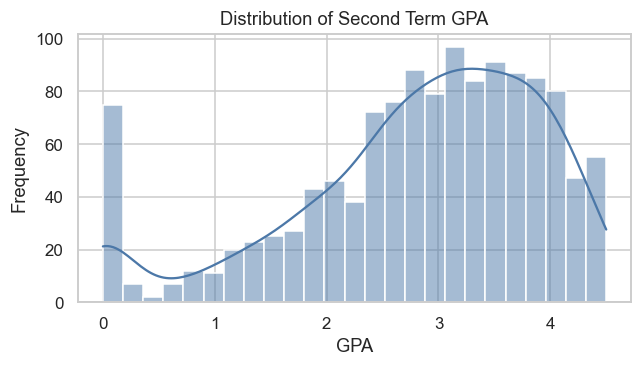

In [10]:
# explorer = DataExplorer(structured_data_file)
# explorer.run_full_analysis()

# Analyze target variable distribution
plt.figure(figsize=(6,3.5))

sns.histplot(y, bins=25, kde=True, color="#4c78a8")
plt.title("Distribution of Second Term GPA")
plt.xlabel("GPA")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [11]:
# number of students have value 0 in second_term_gpa column
num_zero_gpa = (y == 0).sum()
print(f"Number of students with second term GPA of 0: {num_zero_gpa}")

Number of students with second term GPA of 0: 72


### Train-Test Protocol

In [12]:
# test-train split with stratification and train-only feature fitting
X_train_raw, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_raw,
    y_train,
    test_size=0.125,  # 10% of total
    random_state=42,
)

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")

X_train: (893, 12), X_val: (128, 12), X_test: (256, 12)


In [13]:
# check the final training dataset
display(X_train.head())

,first_term_gpa,first_language,funding,fast_track,coop,residency,gender,previous_education,age_group,high_school_average_mark,math_score,english_grade
78,3.521739,3,4.0,1.0,2.0,2.0,1.0,1,3,?,?,7
353,2.25,1,2.0,2.0,2.0,1.0,2.0,2,2,83,?,7
1354,3.4,3,4.0,1.0,2.0,2.0,1.0,2,4,?,?,8
510,4.214286,1,2.0,2.0,1.0,1.0,2.0,2,4,73,49,9
338,2.547619,1,2.0,2.0,1.0,1.0,2.0,1,2,78,27,9


### Data Cleaning

In [14]:
# Data cleaning
cleaner = DataCleaner(numeric_imputer="bayesian")

X_train = cleaner.fit_transform(X_train)
X_val = cleaner.transform(X_val)
X_test = cleaner.transform(X_test)

# Target standardization
scaler = MinMaxScaler()
y_train = scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_val = scaler.transform(y_val.values.reshape(-1, 1)).flatten()
y_test = scaler.transform(y_test.values.reshape(-1, 1)).flatten()


In [100]:
import joblib

# save the preprocessing pipeline (DataCleaner object) to a file for later use in inference
joblib.dump(cleaner, project_path / "second_term_gpa_regression" / "models" / "best_model" / "preprocessing_pipeline.pkl")
joblib.dump(scaler, project_path / "second_term_gpa_regression" / "models" / "best_model" / "target_scaler.pkl")

# check the training after cleaning
display(X_train.head())

,first_term_gpa,fast_track,coop,residency,age_group,high_school_average_mark,math_score,english_grade,first_term_gpa_missing,high_school_average_mark_missing,...,funding_4,funding_5,funding_8,funding_9,gender_1,gender_2,previous_education_0,previous_education_1,previous_education_2,previous_education_3
78,0.485630,1,0,0,3.0,0.335862,0.248844,7.0,0,1,...,True,False,False,False,True,False,False,True,False,False
353,-0.762264,0,0,1,2.0,0.270222,0.122663,7.0,0,0,...,False,False,False,False,False,True,False,False,True,False
1354,0.366174,1,0,0,4.0,0.253814,0.187655,8.0,0,1,...,True,False,False,False,True,False,False,False,True,False
510,1.165193,0,1,1,4.0,-0.751768,1.665857,9.0,0,0,...,False,False,False,False,False,True,False,False,True,False
338,-0.470226,0,1,1,2.0,-0.240773,-0.703704,9.0,0,0,...,False,False,False,False,False,True,False,True,False,False


### Experiment 1: Baseline Model

In [16]:
baseline_layers = [
    {'units': 128, 'activation': 'relu', 'batch_norm': True, 'dropout': 0.2},
    {'units': 64, 'activation': 'relu', 'batch_norm': True, 'dropout': 0.2},
    {'units': 32, 'activation': 'relu', 'batch_norm': False, 'dropout': 0.0},
]

baseline_model = build_dense_model(X_train.shape[1], baseline_layers)
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │           4,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15,489 (60.50 KB)

 Trainable params: 15,105 (59.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [17]:
baseline_model = compile_regression_model(baseline_model, optimizer_name='adam', learning_rate=0.001)

baseline_es, baseline_mc = custom_callback(
    monitor='val_loss',
    mode='min',
    patience=20,
    filepath=project_path / 'second_term_gpa_regression' / 'models' / 'regression_model.keras',
)

history_baseline = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[baseline_es, baseline_mc],
    verbose=1,
)

Epoch 1/200
21/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8828 - mae: 0.7744 - r2: -12.2492 - rmse: 0.9351
Epoch 1: val_loss improved from None to 0.16796, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\regression_model.keras

Epoch 1: finished saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\regression_model.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.5855 - mae: 0.6035 - r2: -7.8885 - rmse: 0.7652 - val_loss: 0.1680 - val_mae: 0.3641 - val_r2: -1.8780 - val_rmse: 0.4098
Epoch 2/200
23/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3417 - mae: 0.4558 - r2: -3.8592 - rmse: 0.5839
Epoch 2: val_loss improved from 0.16796 to 0.13155, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\regression_model.keras

Ep

### Baseline Evaluation

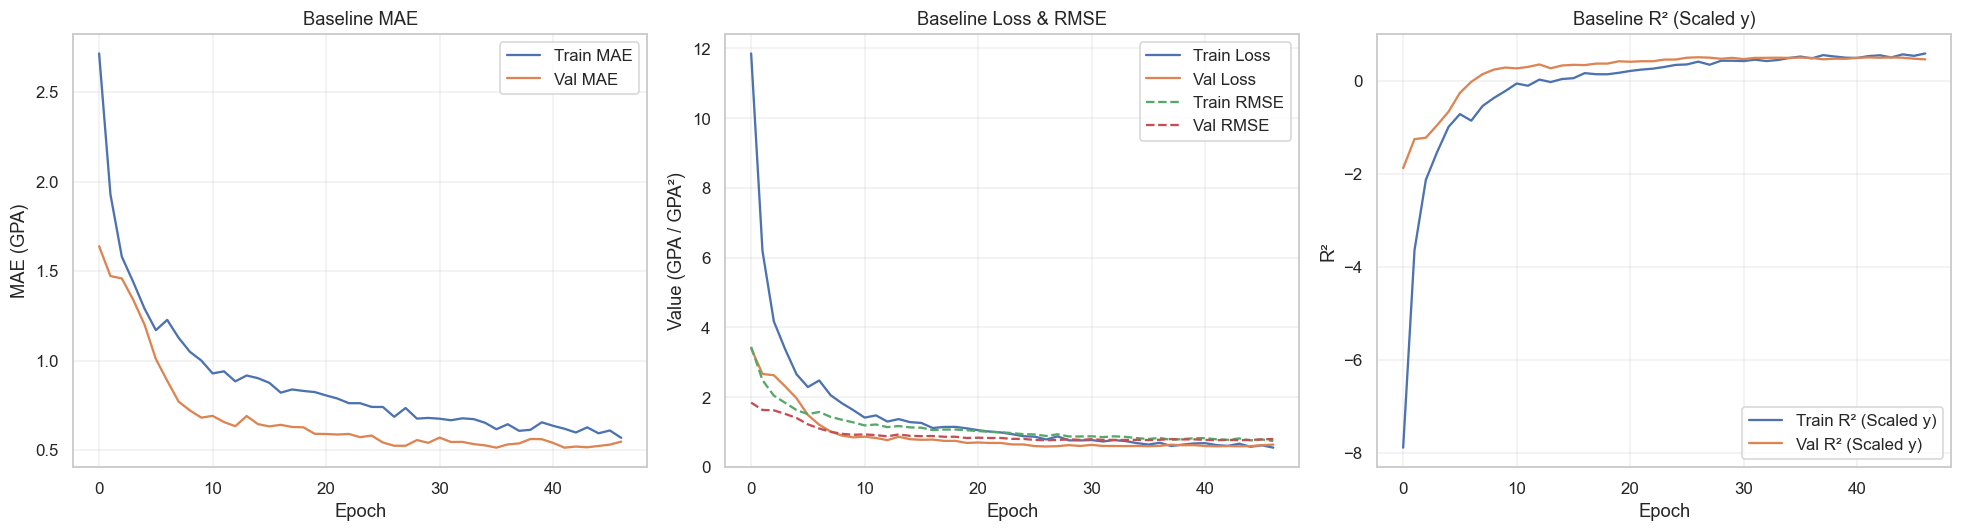


Best Epoch: 27
----------------------------------------
MAE (GPA)   -> Train: 0.6855 | Val: 0.5237
RMSE (GPA)  -> Train: 0.8861 | Val: 0.7642
Loss (GPA²) -> Train: 0.7851 | Val: 0.5840
R² (Scaled y) -> Train: 0.4114 | Val: 0.5058


In [18]:
plot_regression_history(history_baseline, title_prefix='Baseline')

In [19]:
baseline_val_metrics, baseline_val_df = evaluate_model_original_scale(
    baseline_model, X_val, y_val, scaler, split_name='Baseline Validation'
)
baseline_test_metrics, baseline_test_df = evaluate_model_original_scale(
    baseline_model, X_test, y_test, scaler, split_name='Baseline Test'
)

baseline_summary_df = pd.DataFrame([baseline_val_metrics, baseline_test_metrics]).set_index('split')
display(format_metrics_display(baseline_summary_df))
display(baseline_test_df.head(15))

Baseline Validation RMSE: 0.7642
Baseline Validation MSE:  0.5840
Baseline Validation MAE:              0.5237
Baseline Validation R² (Original GPA): 0.5058
Baseline Validation R² (Scaled y):     0.5058
Baseline Test RMSE: 0.6332
Baseline Test MSE:  0.4010
Baseline Test MAE:              0.4904
Baseline Test R² (Original GPA): 0.6365
Baseline Test R² (Scaled y):     0.6365


,RMSE (GPA),MSE (GPA²),MAE (GPA),R² (Original GPA),R² (Scaled y)
split,,,,,
Baseline Validation,0.764231,0.584049,0.523731,0.505797,0.505797
Baseline Test,0.633243,0.400997,0.490418,0.636527,0.636527


,Actual GPA,Predicted GPA,Residual,Absolute Error,Squared Error
0,2.978261,0.867529,2.110732,2.110732,4.455191
1,2.815789,4.777771,-1.961982,1.961982,3.849373
2,3.000000,1.040826,1.959174,1.959174,3.838364
3,2.777778,4.730911,-1.953133,1.953133,3.814730
4,0.000000,1.657256,-1.657256,1.657256,2.746496
5,1.944444,3.556787,-1.612343,1.612343,2.599652
6,1.431818,2.945045,-1.513227,1.513227,2.289857
7,3.375000,1.933890,1.441110,1.441110,2.076799
8,0.000000,1.440853,-1.440853,1.440853,2.076058
9,0.250000,1.632766,-1.382766,1.382766,1.912042


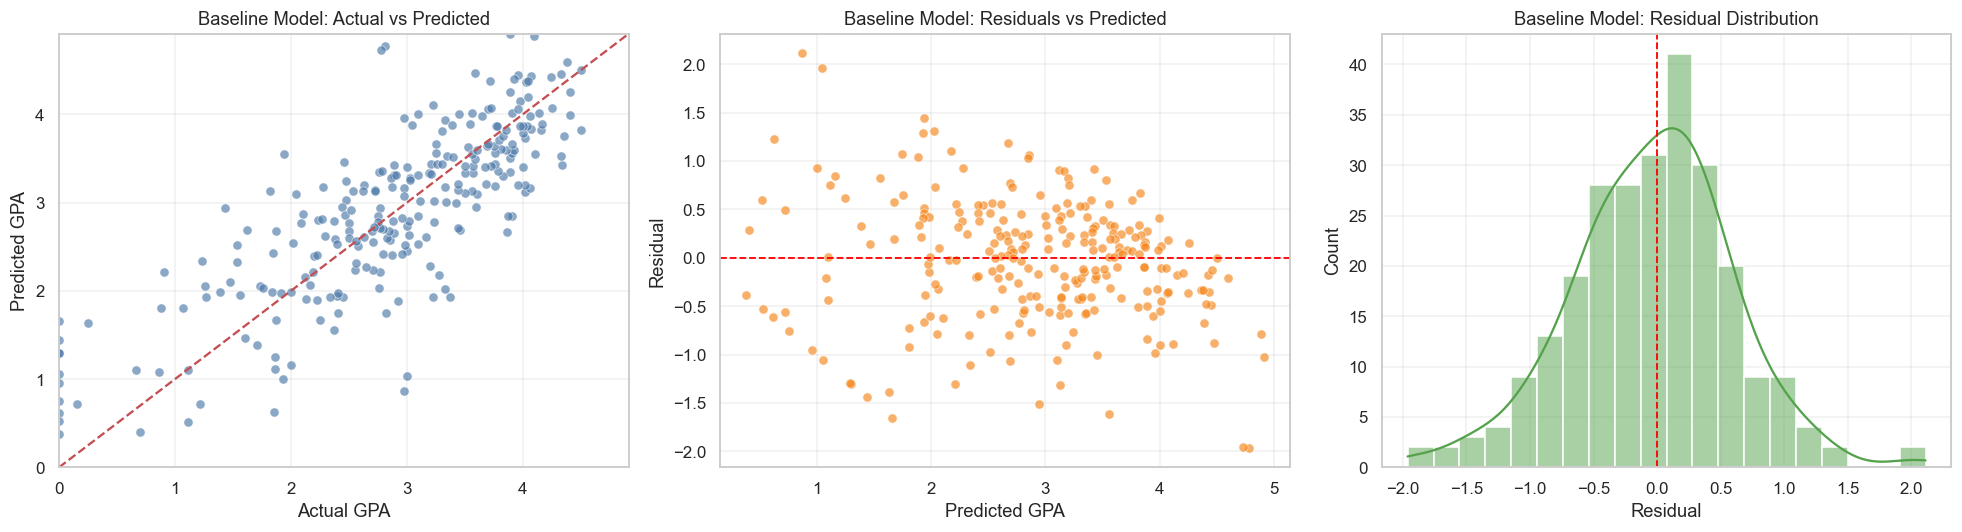

In [20]:
plot_prediction_diagnostics(baseline_test_df, title_prefix='Baseline Model')

### Experiment 2: Keras Tuner - Automatic Hyperband Search

In [21]:
def build_tuner_model(hp):
    layer_specs = []
    num_layers = hp.Int('num_layers', 1, 3)

    for i in range(num_layers):
        layer_specs.append({
            'units': hp.Choice(f'neurons_{i}', [64, 128, 256, 512]),
            'activation': hp.Choice(f'act_{i}', ['relu', 'tanh', 'elu']),
            'batch_norm': True,
            'dropout': hp.Float(f'dropout_{i}', 0.1, 0.5, step=0.1),
        })

    tuner_model = build_dense_model(X_train.shape[1], layer_specs)
    optimizer_name = hp.Choice('optimizer', ['adam', 'sgd', 'rmsprop'])
    learning_rate = hp.Choice('learning_rate', [0.0001, 0.0005, 0.001, 0.002, 0.003, 0.004, 0.005, 0.01])
    tuner_model = compile_regression_model(tuner_model, optimizer_name=optimizer_name, learning_rate=learning_rate)
    return tuner_model


def show_best_hyperparameters(hyperparameters):
    rows = [{'hyperparameter': k, 'value': v} for k, v in hyperparameters.values.items()]
    display(pd.DataFrame(rows))

In [22]:
tuner_dir = project_path / 'second_term_gpa_regression' / 'tuner' / 'student_tuner'
if tuner_dir.exists():
    shutil.rmtree(tuner_dir, ignore_errors=True)

print_header('KERAS TUNER SEARCH')

hyperband_tuner = Hyperband(
    hypermodel=build_tuner_model,
    objective='val_loss',
    max_epochs=40,
    factor=3,
    directory=tuner_dir,
    project_name='student_tuner',
    seed=42,
    overwrite=True,
)

search_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=0,
    mode='min',
)

search_start = time.time()
hyperband_tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    callbacks=[search_stop],
    verbose=1,
)
search_time = time.time() - search_start

print(f'Search completed in {search_time / 60:.1f} minutes')
hyperband_tuner.results_summary(num_trials=10)

best_hps = hyperband_tuner.get_best_hyperparameters(1)[0]
print_header('BEST HYPERPARAMETERS')
show_best_hyperparameters(best_hps)

Trial 90 Complete [00h 00m 15s]
val_loss: 0.023992057889699936

Best val_loss So Far: 0.021207666024565697
Total elapsed time: 00h 10m 20s
Search completed in 10.3 minutes
Results summary
Results in C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\tuner\student_tuner\student_tuner
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 0077 summary
Hyperparameters:
num_layers: 1
neurons_0: 256
act_0: elu
dropout_0: 0.4
optimizer: sgd
learning_rate: 0.001
neurons_1: 64
act_1: relu
dropout_1: 0.4
neurons_2: 256
act_2: elu
dropout_2: 0.4
tuner/epochs: 14
tuner/initial_epoch: 0
tuner/bracket: 1
tuner/round: 0
Score: 0.021207666024565697

Trial 0072 summary
Hyperparameters:
num_layers: 3
neurons_0: 128
act_0: relu
dropout_0: 0.4
optimizer: sgd
learning_rate: 0.002
neurons_1: 512
act_1: tanh
dropout_1: 0.2
neurons_2: 64
act_2: relu
dropout_2: 0.5
tuner/epochs: 40
tuner/initial_epoch: 14
tuner/bracket: 2
tune

,hyperparameter,value
0,num_layers,1
1,neurons_0,256
2,act_0,elu
3,dropout_0,0.4
4,optimizer,sgd
5,learning_rate,0.001
6,neurons_1,64
7,act_1,relu
8,dropout_1,0.4
9,neurons_2,256


### Hyperband Results

In [23]:
all_trials = list(hyperband_tuner.oracle.trials.values())
target_scale = get_target_scale(scaler)
mse_scale = target_scale ** 2

tuning_results_df = pd.DataFrame([
    {
        'Loss (GPA²)': (t.metrics.metrics['loss'].get_best_value() * mse_scale) if 'loss' in t.metrics.metrics else None,
        'Val_Loss (GPA²)': (t.metrics.metrics['val_loss'].get_best_value() * mse_scale) if 'val_loss' in t.metrics.metrics else None,
        'MAE (GPA)': (t.metrics.metrics['mae'].get_best_value() * target_scale) if 'mae' in t.metrics.metrics else None,
        'Val_MAE (GPA)': (t.metrics.metrics['val_mae'].get_best_value() * target_scale) if 'val_mae' in t.metrics.metrics else None,
        'RMSE (GPA)': (t.metrics.metrics['rmse'].get_best_value() * target_scale) if 'rmse' in t.metrics.metrics else None,
        'Val_RMSE (GPA)': (t.metrics.metrics['val_rmse'].get_best_value() * target_scale) if 'val_rmse' in t.metrics.metrics else None,
        'R2 (Scaled y)': t.metrics.metrics['r2'].get_best_value() if 'r2' in t.metrics.metrics else None,
        'Val_R2 (Scaled y)': t.metrics.metrics['val_r2'].get_best_value() if 'val_r2' in t.metrics.metrics else None,
        **t.hyperparameters.values,
    }
    for t in all_trials
]).sort_values('Val_Loss (GPA²)', ascending=True).reset_index(drop=True)

tuning_results_df.insert(0, 'ID', range(1, len(tuning_results_df) + 1))
tuning_results_df.to_csv(
    project_path / 'second_term_gpa_regression' / 'trial_results' / 'keras_tuner_results_regression_bayesian.csv',
    index=False,
)

print('TOP 20 BEST TRIALS (loss/MAE/RMSE in original GPA scale, R² in scaled y)')
print(tuning_results_df.head(20).to_string(index=False))

TOP 20 BEST TRIALS (loss/MAE/RMSE in original GPA scale, R² in scaled y)
 ID  Loss (GPA²)  Val_Loss (GPA²)  MAE (GPA)  Val_MAE (GPA)  RMSE (GPA)  Val_RMSE (GPA)  R2 (Scaled y)  Val_R2 (Scaled y)  num_layers  neurons_0 act_0  dropout_0 optimizer  learning_rate  tuner/epochs  tuner/initial_epoch  tuner/bracket  tuner/round  neurons_1 act_1  dropout_1  neurons_2 act_2  dropout_2 tuner/trial_id
  1     0.574422         0.429455   0.578936       0.460115    0.757906        0.655328       0.569363           0.636609           1        256   elu        0.4       sgd          0.001            14                    0              1            0         64  relu        0.4      256.0   elu        0.4            NaN
  2     0.689254         0.430980   0.631300       0.468482    0.830213        0.656491       0.483273           0.635318           3        128  relu        0.4       sgd          0.002            40                   14              2            2        512  tanh        0.2       6

In [24]:
best_model = hyperband_tuner.hypermodel.build(best_hps)
best_model.summary()

best_es, best_mc = custom_callback(
    monitor='val_loss',
    mode='min',
    patience=20,
    filepath=project_path / 'second_term_gpa_regression' / 'models' / 'best_regression_model_bayesian.keras',
)

history_best = best_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    callbacks=[best_es, best_mc],
    verbose=1,
)

print('Training completed.')

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 256)                 │           8,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9,985 (39.00 KB)

 Trainable params: 9,473 (37.00 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/200
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.5236 - mae: 1.1916 - r2: -45.5452 - rmse: 1.5841
Epoch 1: val_loss improved from None to 0.07862, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\best_regression_model_bayesian.keras

Epoch 1: finished saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\best_regression_model_bayesian.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 1.9287 - mae: 1.0445 - r2: -28.2801 - rmse: 1.3888 - val_loss: 0.0786 - val_mae: 0.2260 - val_r2: -0.3471 - val_rmse: 0.2804
Epoch 2/200
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8042 - mae: 0.6903 - r2: -10.6831 - rmse: 0.8959
Epoch 2: val_loss did not improve from 0.07862
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6965 - mae: 0.6300 - r2: -9.5730 - rmse: 0.8345 - val_loss: 0.1038 - val_mae: 0.2807 - val_

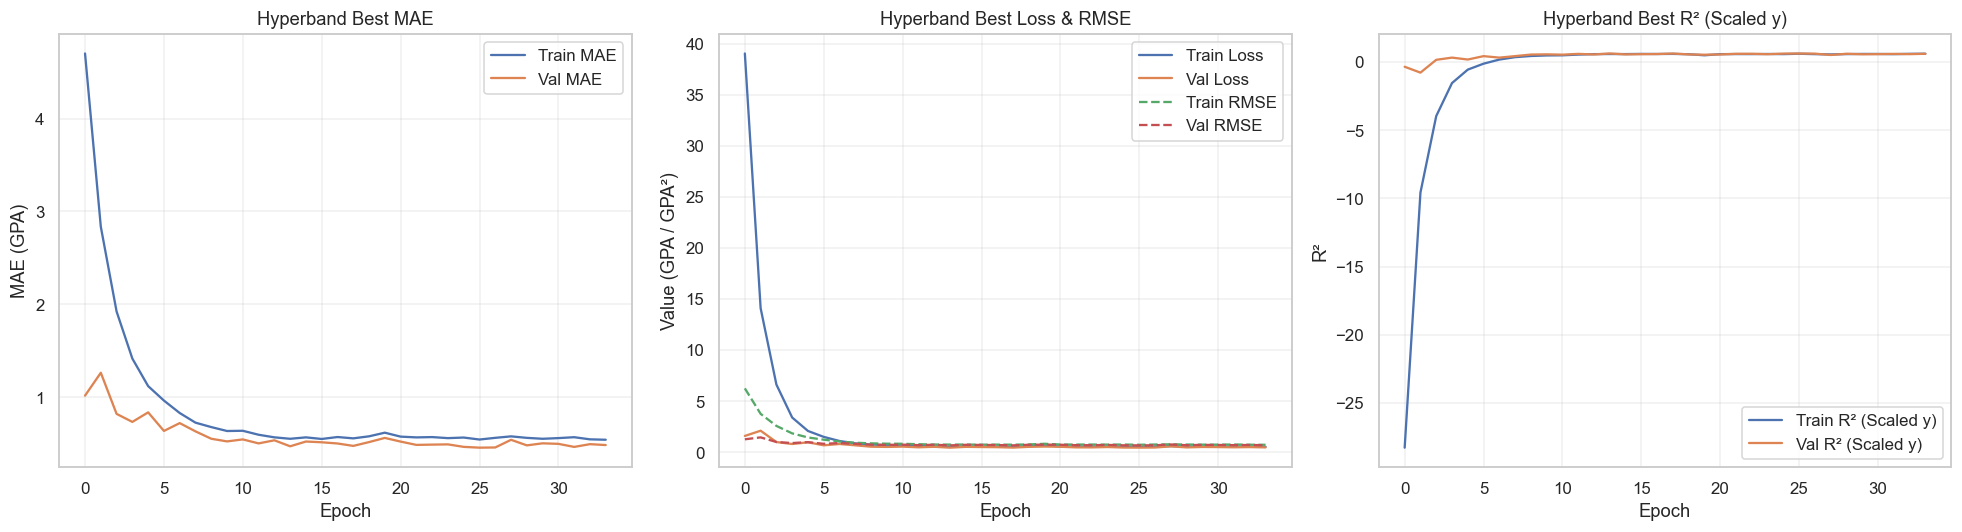


Best Epoch: 14
----------------------------------------
MAE (GPA)   -> Train: 0.5521 | Val: 0.4713
RMSE (GPA)  -> Train: 0.7427 | Val: 0.6650
Loss (GPA²) -> Train: 0.5516 | Val: 0.4422
R² (Scaled y) -> Train: 0.5865 | Val: 0.6258


In [25]:
plot_regression_history(history_best, title_prefix='Hyperband Best')

In [26]:
best_val_metrics, best_val_df = evaluate_model_original_scale(
    best_model, X_val, y_val, scaler, split_name='Hyperband Validation'
)
best_test_metrics, best_test_df = evaluate_model_original_scale(
    best_model, X_test, y_test, scaler, split_name='Hyperband Test'
)

best_summary_df = pd.DataFrame([best_val_metrics, best_test_metrics]).set_index('split')
display(format_metrics_display(best_summary_df))
display(best_test_df.head(15))

Hyperband Validation RMSE: 0.6650
Hyperband Validation MSE:  0.4422
Hyperband Validation MAE:              0.4713
Hyperband Validation R² (Original GPA): 0.6258
Hyperband Validation R² (Scaled y):     0.6258
Hyperband Test RMSE: 0.5891
Hyperband Test MSE:  0.3470
Hyperband Test MAE:              0.4577
Hyperband Test R² (Original GPA): 0.6855
Hyperband Test R² (Scaled y):     0.6855


,RMSE (GPA),MSE (GPA²),MAE (GPA),R² (Original GPA),R² (Scaled y)
split,,,,,
Hyperband Validation,0.664959,0.442170,0.471287,0.625850,0.625850
Hyperband Test,0.589069,0.347002,0.457702,0.685469,0.685469


,Actual GPA,Predicted GPA,Residual,Absolute Error,Squared Error
0,0.000000,1.875350,-1.875350,1.875350,3.516939
1,0.000000,1.875297,-1.875297,1.875297,3.516738
2,0.250000,2.070689,-1.820689,1.820689,3.314910
3,0.000000,1.755116,-1.755116,1.755116,3.080431
4,3.000000,1.364929,1.635071,1.635071,2.673458
5,0.000000,1.623846,-1.623846,1.623846,2.636875
6,2.978261,1.583644,1.394617,1.394617,1.944957
7,1.619048,2.963421,-1.344373,1.344373,1.807340
8,0.000000,1.280538,-1.280538,1.280538,1.639777
9,0.000000,1.250545,-1.250545,1.250545,1.563863


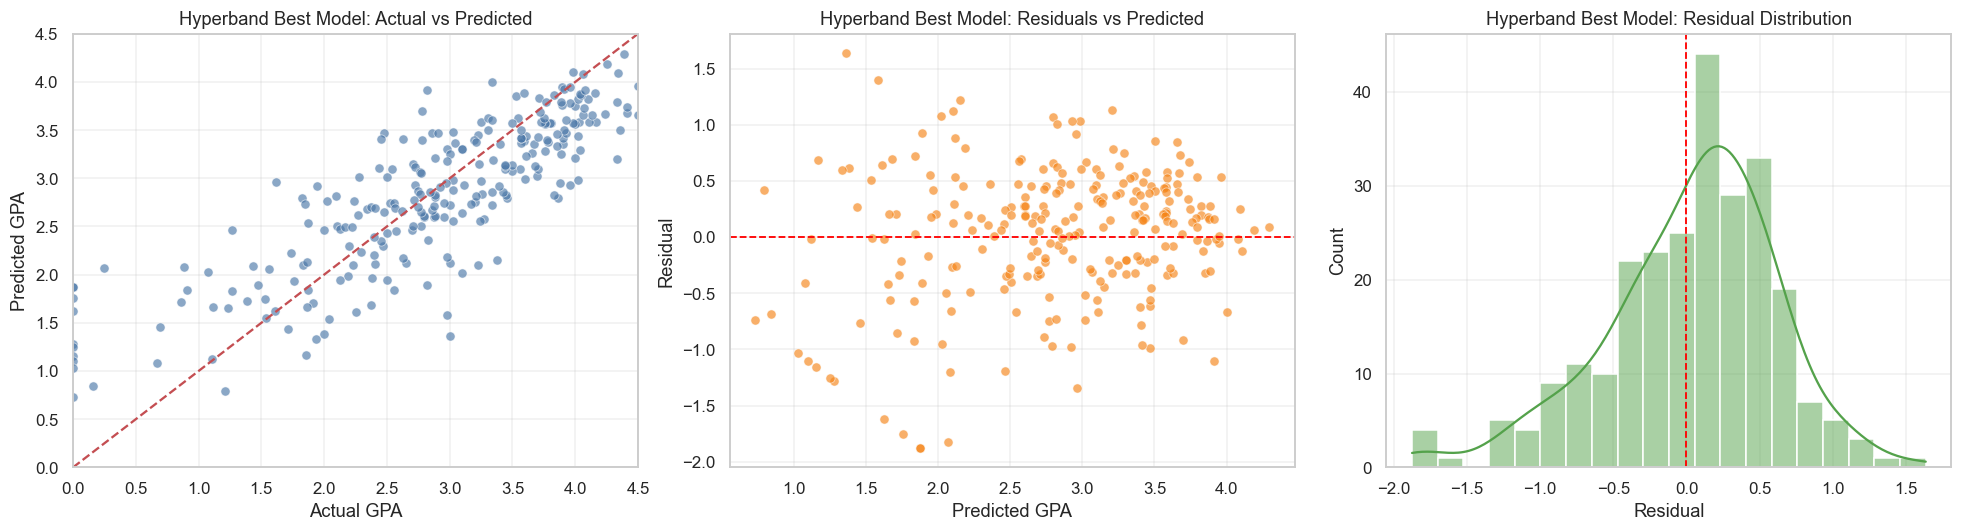

In [27]:
plot_prediction_diagnostics(best_test_df, title_prefix='Hyperband Best Model')

### Experiment 3: Custom Model based on Hyperband Findings

In [89]:
custom_layers = [
    {'units': 516, 'activation': 'tanh', 'batch_norm': True, 'dropout': 0.1},
    {'units': 128, 'activation': 'elu', 'batch_norm': True, 'dropout': 0.2},
]

custom_model = build_dense_model(X_train.shape[1], custom_layers)
custom_model.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_48 (Dense)                     │ (None, 516)                 │          17,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_32               │ (None, 516)                 │           2,064 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_32 (Dropout)                 │ (None, 516)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_49 (Dense)                     │ (None, 128)                 │          66,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_33               │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_33 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_50 (Dense)                     │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 86,425 (337.60 KB)

 Trainable params: 85,137 (332.57 KB)

 Non-trainable params: 1,288 (5.03 KB)

In [90]:
custom_model = compile_regression_model(custom_model, optimizer_name='sgd', learning_rate=0.0009)

custom_es, custom_mc = custom_callback(
    monitor='val_loss',
    mode='min',
    patience=20,
    filepath=project_path / 'second_term_gpa_regression' / 'models' / 'best_model' / 'custom_model_bayesian.keras',
)

history_custom = custom_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    callbacks=[custom_es, custom_mc],
    verbose=1,
)

Epoch 1/200
20/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7688 - mae: 1.0261 - r2: -25.8129 - rmse: 1.3247
Epoch 1: val_loss improved from None to 0.05097, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\best_model\custom_model_bayesian.keras

Epoch 1: finished saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\best_model\custom_model_bayesian.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 1.1509 - mae: 0.8261 - r2: -16.4715 - rmse: 1.0728 - val_loss: 0.0510 - val_mae: 0.1805 - val_r2: 0.1266 - val_rmse: 0.2258
Epoch 2/200
26/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4785 - mae: 0.5302 - r2: -7.5391 - rmse: 0.6909
Epoch 2: val_loss improved from 0.05097 to 0.03429, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\m

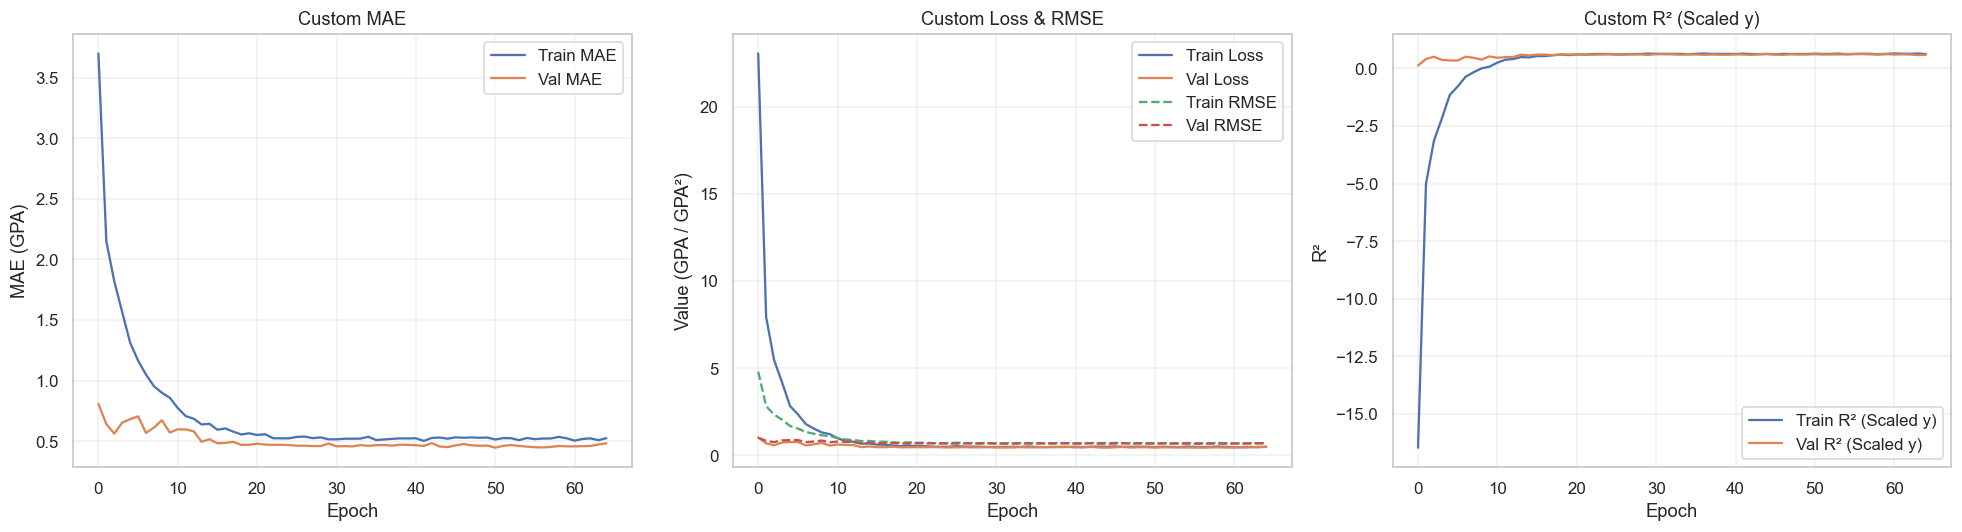


Best Epoch: 45
----------------------------------------
MAE (GPA)   -> Train: 0.5205 | Val: 0.4509
RMSE (GPA)  -> Train: 0.6975 | Val: 0.6617
Loss (GPA²) -> Train: 0.4865 | Val: 0.4379
R² (Scaled y) -> Train: 0.6315 | Val: 0.6257


In [91]:
plot_regression_history(history_custom, title_prefix='Custom')

In [92]:
custom_val_metrics, custom_val_df = evaluate_model_original_scale(
    custom_model, X_val, y_val, scaler, split_name='Custom Validation'
)
custom_test_metrics, custom_test_df = evaluate_model_original_scale(
    custom_model, X_test, y_test, scaler, split_name='Custom Test'
)

custom_summary_df = pd.DataFrame([custom_val_metrics, custom_test_metrics]).set_index('split')
display(format_metrics_display(custom_summary_df))
display(custom_test_df.head(15))

Custom Validation RMSE: 0.6617
Custom Validation MSE:  0.4379
Custom Validation MAE:              0.4509
Custom Validation R² (Original GPA): 0.6257
Custom Validation R² (Scaled y):     0.6257
Custom Test RMSE: 0.5587
Custom Test MSE:  0.3121
Custom Test MAE:              0.4236
Custom Test R² (Original GPA): 0.7142
Custom Test R² (Scaled y):     0.7142


,RMSE (GPA),MSE (GPA²),MAE (GPA),R² (Original GPA),R² (Scaled y)
split,,,,,
Custom Validation,0.661708,0.437857,0.450909,0.625670,0.625670
Custom Test,0.558661,0.312102,0.423561,0.714179,0.714179


,Actual GPA,Predicted GPA,Residual,Absolute Error,Squared Error
0,0.000000,1.930816,-1.930816,1.930816,3.728051
1,2.984615,1.084356,1.900259,1.900259,3.610985
2,0.000000,1.822191,-1.822191,1.822191,3.320380
3,0.248718,1.993422,-1.744704,1.744704,3.043994
4,0.000000,1.647230,-1.647230,1.647230,2.713366
5,2.962988,1.424448,1.538540,1.538540,2.367105
6,0.000000,1.475533,-1.475533,1.475533,2.177196
7,3.357692,2.113074,1.244618,1.244618,1.549073
8,3.205698,2.013984,1.191713,1.191713,1.420181
9,3.079365,1.892359,1.187005,1.187005,1.408982


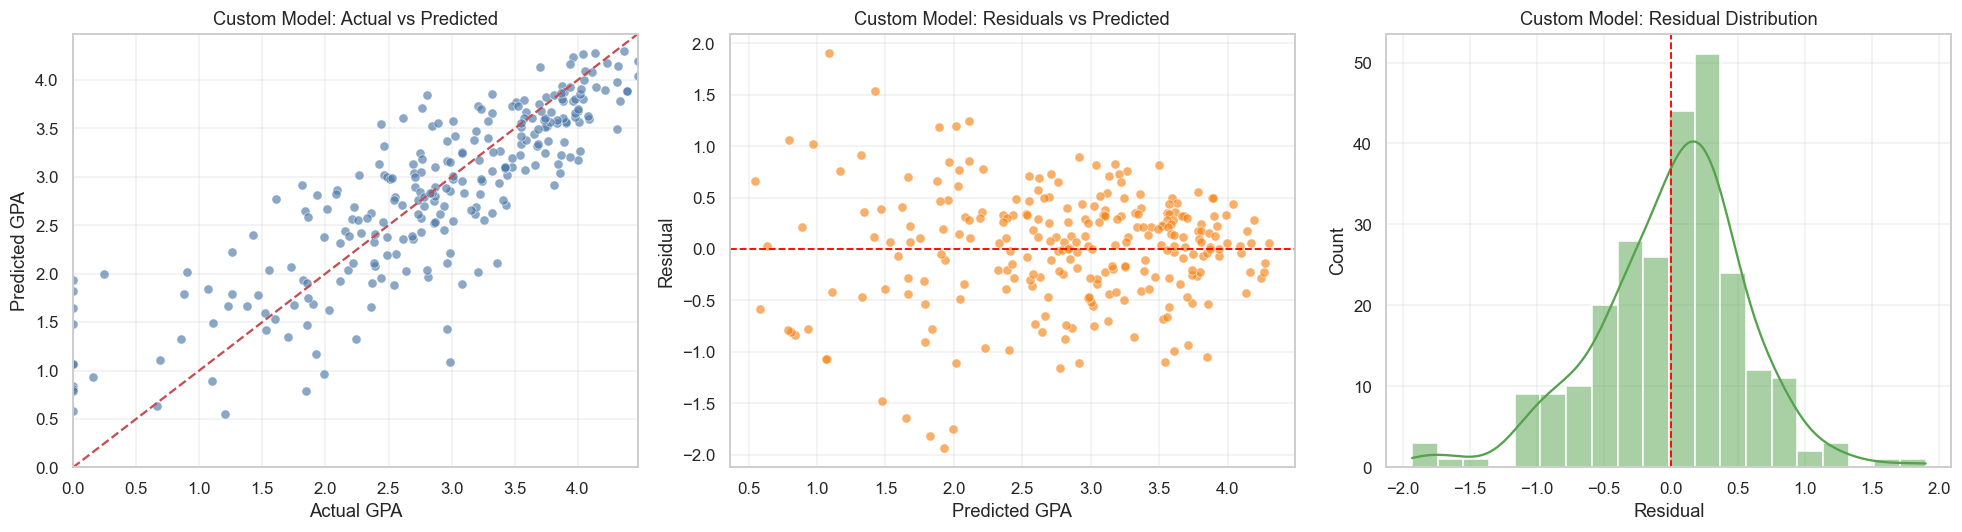

In [93]:
plot_prediction_diagnostics(custom_test_df, title_prefix='Custom Model')

### Experiment 4: Local Search around the Custom Architecture

In [33]:
# trying to find the local minimum around the custom model configuration by varying learning rate and batch size

base_layers = [
    {'units': 516, 'activation': 'tanh', 'batch_norm': True, 'dropout': 0.10},
    {'units': 128, 'activation': 'elu', 'batch_norm': True, 'dropout': 0.20},
]

local_search_configs = [
    {'trial_name': 'SGD-lr0.00085-bs64', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.00085, 'batch_size': 64},
    {'trial_name': 'SGD-lr0.00088-bs64', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.00088, 'batch_size': 64},
    {'trial_name': 'SGD-lr0.00090-bs64', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.00090, 'batch_size': 64},
    {'trial_name': 'SGD-lr0.00092-bs64', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.00092, 'batch_size': 64},
    {'trial_name': 'SGD-lr0.00095-bs64', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.00095, 'batch_size': 64},

    {'trial_name': 'SGD-lr0.00090-bs32', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.00090, 'batch_size': 32},
    {'trial_name': 'SGD-lr0.00090-bs64', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.00090, 'batch_size': 64},
    {'trial_name': 'SGD-lr0.00090-bs96', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.00090, 'batch_size': 96},
    {'trial_name': 'SGD-lr0.00090-bs128', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.00090, 'batch_size': 128},
]

local_search_results = []
local_search_models = {}
local_search_histories = {}
best_local_model = None
best_local_history = None
best_local_metrics = None
best_local_config = None
best_local_sort_key = None

for trial_idx, config in enumerate(local_search_configs, start=1):
    print_header(config['trial_name'])

    trial_model = build_dense_model(X_train.shape[1], config['layers'])
    trial_model = compile_regression_model(trial_model, optimizer_name=config['optimizer'], learning_rate=config['learning_rate'])

    trial_es = EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=1,
        mode='min',
    )

    trial_history = trial_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=200,
        batch_size=config['batch_size'],
        callbacks=[trial_es],
        verbose=1,
    )

    trial_val_metrics, _ = evaluate_model_original_scale(
        trial_model, X_val, y_val, scaler, split_name=f"{config['trial_name']} Validation", print_summary=False
    )
    trial_test_metrics, _ = evaluate_model_original_scale(
        trial_model, X_test, y_test, scaler, split_name=f"{config['trial_name']} Test", print_summary=False
    )

    best_epoch = int(np.argmin(trial_history.history['val_loss'])) + 1
    local_result = {
        'trial': trial_idx,
        'trial_name': config['trial_name'],
        'optimizer': config['optimizer'],
        'learning_rate': config['learning_rate'],
        'batch_size': config['batch_size'],
        'best_epoch': best_epoch,
        'val_rmse': trial_val_metrics['rmse'],
        'val_mae': trial_val_metrics['mae'],
        'val_r2_original': trial_val_metrics['r2_original'],
        'val_r2_scaled': trial_val_metrics['r2_scaled'],
        'test_rmse': trial_test_metrics['rmse'],
        'test_mae': trial_test_metrics['mae'],
        'test_r2_original': trial_test_metrics['r2_original'],
        'test_r2_scaled': trial_test_metrics['r2_scaled'],
        'architecture': ' | '.join([f"{layer['units']}:{layer['activation']}" for layer in config['layers']]),
    }
    local_search_results.append(local_result)
    local_search_models[config['trial_name']] = trial_model
    local_search_histories[config['trial_name']] = trial_history

    sort_key = (trial_val_metrics['r2_original'], -trial_val_metrics['rmse'])
    if best_local_sort_key is None or sort_key > best_local_sort_key:
        best_local_sort_key = sort_key
        best_local_model = trial_model
        best_local_history = trial_history
        best_local_metrics = local_result
        best_local_config = config

local_search_results_df = pd.DataFrame(local_search_results).sort_values(['val_r2_original', 'val_rmse'], ascending=[False, True]).reset_index(drop=True)
local_search_results_df.to_csv(
    project_path / 'second_term_gpa_regression' / 'trial_results' / 'local_search_results_regression_bayesian.csv',
    index=False,
)


========================== SGD-lr0.00085-bs64 ==========================

Epoch 1/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 1.4788 - mae: 0.9398 - r2: -21.4496 - rmse: 1.2161 - val_loss: 0.9541 - val_mae: 0.9295 - val_r2: -15.3476 - val_rmse: 0.9768
Epoch 2/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.7367 - mae: 0.6715 - r2: -10.1845 - rmse: 0.8583 - val_loss: 0.2273 - val_mae: 0.4334 - val_r2: -2.8955 - val_rmse: 0.4768
Epoch 3/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.5387 - mae: 0.5669 - r2: -7.1787 - rmse: 0.7340 - val_loss: 0.1876 - val_mae: 0.3882 - val_r2: -2.2150 - val_rmse: 0.4332
Epoch 4/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.4419 - mae: 0.5098 - r2: -5.7086 - rmse: 0.6648 - val_loss: 0.0792 - val_mae: 0.2451 - val_r2: -0.3571 - val_rmse: 0.2814
Epoch 5/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.3205 - mae: 0.4355 - r2: -3.8649 - rmse: 0.5661 - val_loss: 0.0685 - val_mae: 0.2237 - val_r2: -0.1735 - val_rmse: 0.2617
Ep

In [34]:
# Save the best local search model
best_local_model.save(project_path / 'second_term_gpa_regression' / 'models' / 'local_search_model_bayesian.keras')

print('BEST LOCAL SEARCH CONFIG')
for key, value in best_local_config.items():
    print(f"{key}: {value}")

display(format_local_search_display(local_search_results_df))

BEST LOCAL SEARCH CONFIG
trial_name: SGD-lr0.00085-bs64
layers: [{'units': 516, 'activation': 'tanh', 'batch_norm': True, 'dropout': 0.1}, {'units': 128, 'activation': 'elu', 'batch_norm': True, 'dropout': 0.2}]
optimizer: sgd
learning_rate: 0.00085
batch_size: 64


,Trial,Trial Name,Optimizer,Learning Rate,Batch Size,Best Epoch,Val RMSE (GPA),Val MAE (GPA),Val R² (Original GPA),Val R² (Scaled y),Test RMSE (GPA),Test MAE (GPA),Test R² (Original GPA),Test R² (Scaled y),Architecture
0,1,SGD-lr0.00085-bs64,sgd,0.00085,64,70,0.666336,0.452504,0.624298,0.624298,0.568053,0.433821,0.707511,0.707511,516:tanh | 128:elu
1,2,SGD-lr0.00088-bs64,sgd,0.00088,64,51,0.670380,0.464854,0.619724,0.619724,0.576658,0.439638,0.698583,0.698583,516:tanh | 128:elu
2,4,SGD-lr0.00092-bs64,sgd,0.00092,64,57,0.670736,0.453257,0.619321,0.619321,0.574442,0.441376,0.700895,0.700895,516:tanh | 128:elu
3,8,SGD-lr0.00090-bs96,sgd,0.00090,96,81,0.673470,0.459597,0.616210,0.616210,0.572793,0.445091,0.702610,0.702610,516:tanh | 128:elu
4,7,SGD-lr0.00090-bs64,sgd,0.00090,64,62,0.674629,0.468239,0.614888,0.614888,0.575109,0.437222,0.700200,0.700200,516:tanh | 128:elu
5,9,SGD-lr0.00090-bs128,sgd,0.00090,128,108,0.674653,0.461528,0.614861,0.614861,0.570298,0.440749,0.705195,0.705195,516:tanh | 128:elu
6,6,SGD-lr0.00090-bs32,sgd,0.00090,32,27,0.674934,0.471335,0.614540,0.614540,0.577471,0.447164,0.697733,0.697733,516:tanh | 128:elu
7,3,SGD-lr0.00090-bs64,sgd,0.00090,64,44,0.678652,0.471768,0.610282,0.610282,0.572302,0.445301,0.703119,0.703119,516:tanh | 128:elu
8,5,SGD-lr0.00095-bs64,sgd,0.00095,64,56,0.680134,0.470076,0.608578,0.608578,0.574754,0.446098,0.700570,0.700570,516:tanh | 128:elu


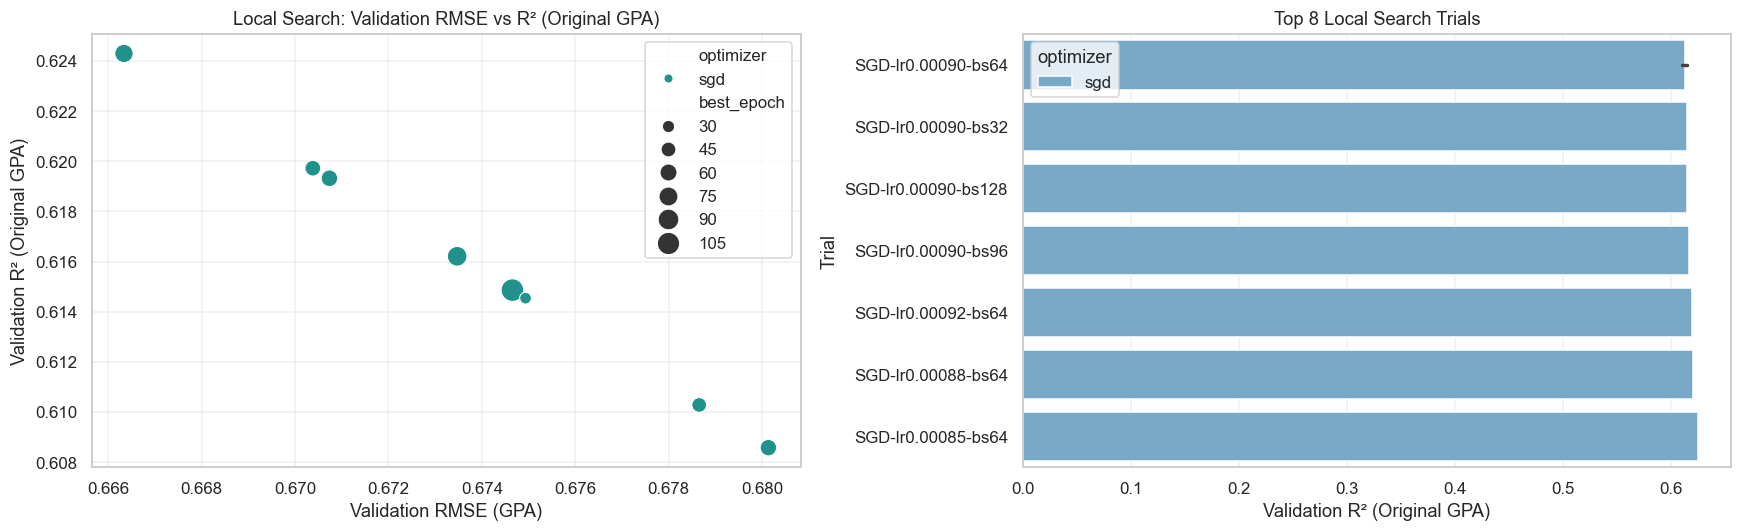

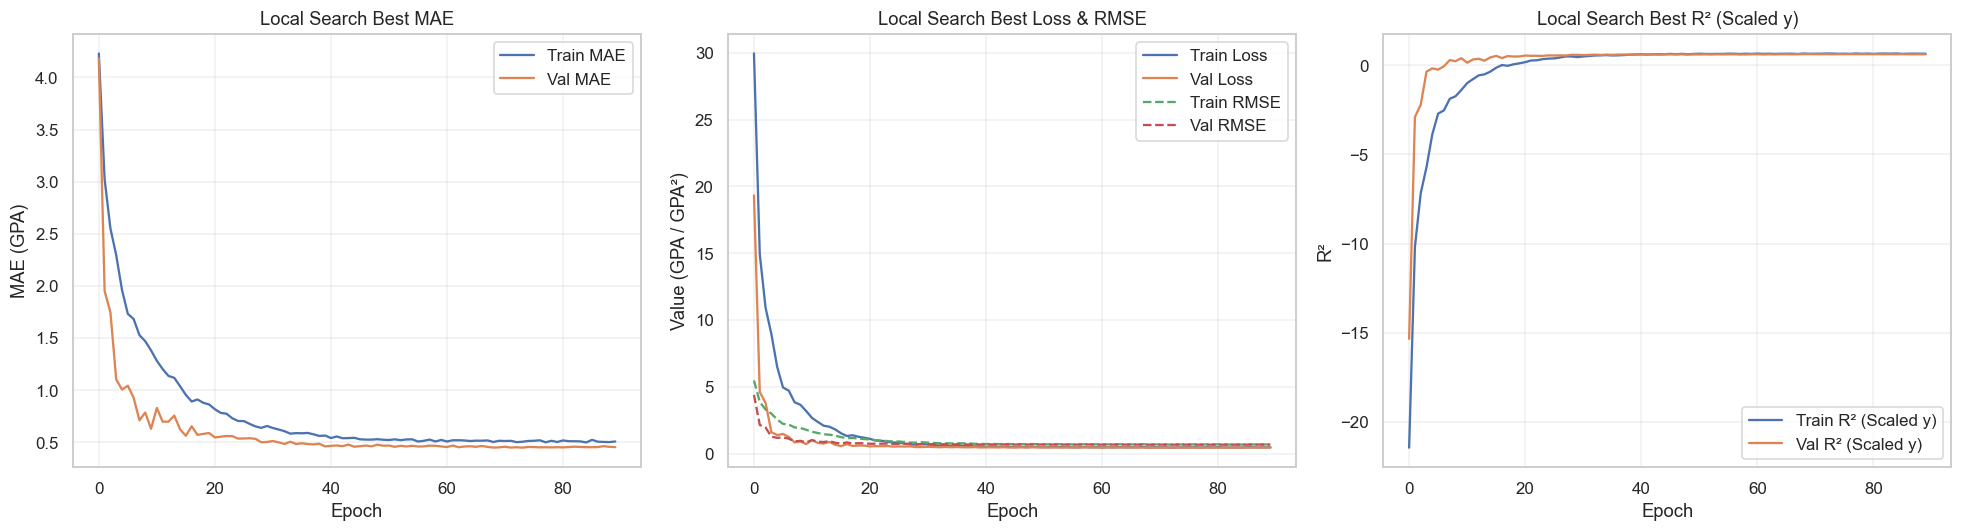


Best Epoch: 70
----------------------------------------
MAE (GPA)   -> Train: 0.5156 | Val: 0.4525
RMSE (GPA)  -> Train: 0.6894 | Val: 0.6663
Loss (GPA²) -> Train: 0.4753 | Val: 0.4440
R² (Scaled y) -> Train: 0.6437 | Val: 0.6243


In [35]:
plot_local_search_summary(local_search_results_df)
plot_regression_history(best_local_history, title_prefix='Local Search Best')

In [36]:
local_val_metrics, local_val_df = evaluate_model_original_scale(
    best_local_model, X_val, y_val, scaler, split_name='Local Search Validation'
)
local_test_metrics, local_test_df = evaluate_model_original_scale(
    best_local_model, X_test, y_test, scaler, split_name='Local Search Test'
)

local_summary_df = pd.DataFrame([local_val_metrics, local_test_metrics]).set_index('split')
display(format_metrics_display(local_summary_df))
display(local_test_df.head(15))

Local Search Validation RMSE: 0.6663
Local Search Validation MSE:  0.4440
Local Search Validation MAE:              0.4525
Local Search Validation R² (Original GPA): 0.6243
Local Search Validation R² (Scaled y):     0.6243
Local Search Test RMSE: 0.5681
Local Search Test MSE:  0.3227
Local Search Test MAE:              0.4338
Local Search Test R² (Original GPA): 0.7075
Local Search Test R² (Scaled y):     0.7075


,RMSE (GPA),MSE (GPA²),MAE (GPA),R² (Original GPA),R² (Scaled y)
split,,,,,
Local Search Validation,0.666336,0.444004,0.452504,0.624298,0.624298
Local Search Test,0.568053,0.322684,0.433821,0.707511,0.707511


,Actual GPA,Predicted GPA,Residual,Absolute Error,Squared Error
0,0.000000,2.011586,-2.011586,2.011586,4.046480
1,3.000000,1.122077,1.877923,1.877923,3.526595
2,0.250000,2.034273,-1.784273,1.784273,3.183631
3,0.000000,1.666461,-1.666461,1.666461,2.777094
4,0.000000,1.595150,-1.595150,1.595150,2.544505
5,0.000000,1.560817,-1.560817,1.560817,2.436151
6,2.978261,1.453234,1.525027,1.525027,2.325707
7,1.619048,2.964622,-1.345574,1.345574,1.810569
8,3.375000,2.107659,1.267341,1.267341,1.606152
9,2.454545,3.717008,-1.262463,1.262463,1.593812


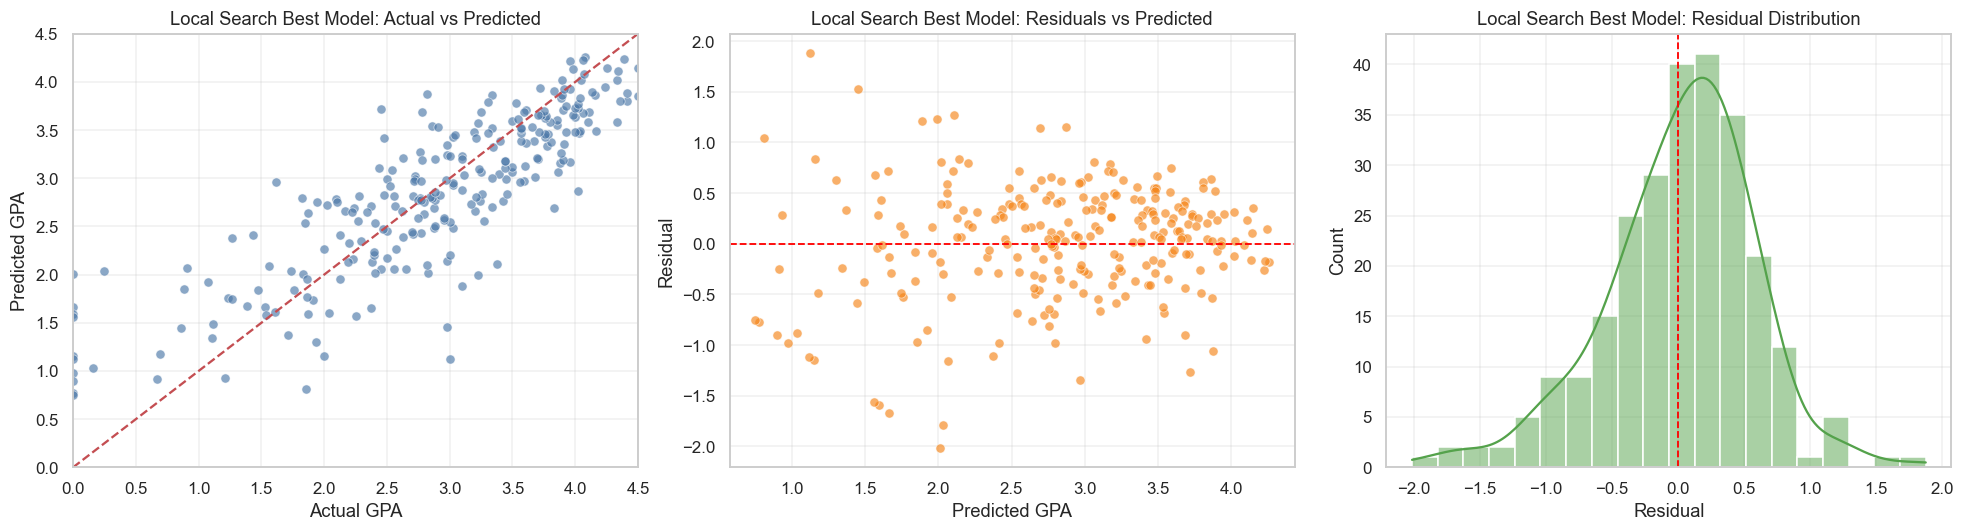

In [37]:
plot_prediction_diagnostics(local_test_df, title_prefix='Local Search Best Model')

### Model Comparison and Grouped Feature Importance

,Model,Split,RMSE (GPA),MSE (GPA²),MAE (GPA),R² (Original GPA),R² (Scaled y)
0,Baseline,Validation,0.764231,0.584049,0.523731,0.505797,0.505797
1,Baseline,Test,0.633243,0.400997,0.490418,0.636527,0.636527
2,Hyperband Best,Validation,0.664959,0.442170,0.471287,0.625850,0.625850
3,Hyperband Best,Test,0.589069,0.347002,0.457702,0.685469,0.685469
4,Custom,Validation,0.661708,0.437857,0.450909,0.625670,0.625670
5,Custom,Test,0.558661,0.312102,0.423561,0.714179,0.714179
6,Local Search,Validation,0.666336,0.444004,0.452504,0.624298,0.624298
7,Local Search,Test,0.568053,0.322684,0.433821,0.707511,0.707511


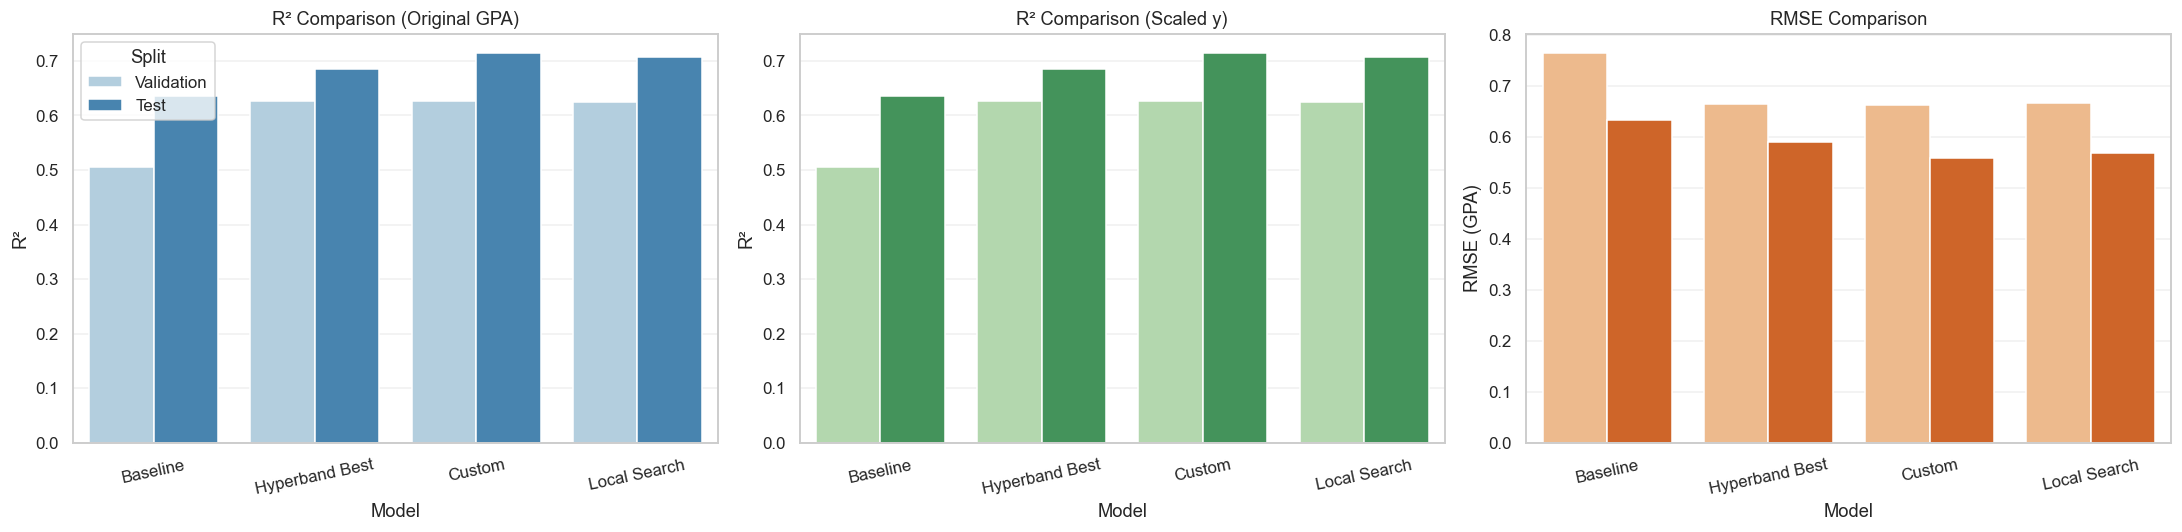

,Model,Split,RMSE (GPA),MSE (GPA²),MAE (GPA),R² (Original GPA),R² (Scaled y)
0,Custom,Test,0.558661,0.312102,0.423561,0.714179,0.714179
1,Local Search,Test,0.568053,0.322684,0.433821,0.707511,0.707511
2,Hyperband Best,Test,0.589069,0.347002,0.457702,0.685469,0.685469
3,Baseline,Test,0.633243,0.400997,0.490418,0.636527,0.636527


In [94]:
experiment_models = {
    'Baseline': baseline_model,
    'Hyperband Best': best_model,
    'Custom': custom_model,
    'Local Search': best_local_model,
}

comparison_df = pd.DataFrame([
    {'Model': 'Baseline', 'Split': 'Validation', **{k: v for k, v in baseline_val_metrics.items() if k != 'split'}},
    {'Model': 'Baseline', 'Split': 'Test', **{k: v for k, v in baseline_test_metrics.items() if k != 'split'}},
    {'Model': 'Hyperband Best', 'Split': 'Validation', **{k: v for k, v in best_val_metrics.items() if k != 'split'}},
    {'Model': 'Hyperband Best', 'Split': 'Test', **{k: v for k, v in best_test_metrics.items() if k != 'split'}},
    {'Model': 'Custom', 'Split': 'Validation', **{k: v for k, v in custom_val_metrics.items() if k != 'split'}},
    {'Model': 'Custom', 'Split': 'Test', **{k: v for k, v in custom_test_metrics.items() if k != 'split'}},
    {'Model': 'Local Search', 'Split': 'Validation', **{k: v for k, v in local_val_metrics.items() if k != 'split'}},
    {'Model': 'Local Search', 'Split': 'Test', **{k: v for k, v in local_test_metrics.items() if k != 'split'}},
])

display(format_metrics_display(comparison_df))
plot_experiment_comparison(comparison_df)

validation_rank_df = comparison_df[comparison_df['Split'] == 'Test'].sort_values(['r2_original', 'rmse'], ascending=[False, True]).reset_index(drop=True)
display(format_metrics_display(validation_rank_df))

Selected model for grouped feature importance: Custom


,Feature Group,RMSE Increase (Mean),RMSE Increase (Std),R² Drop (Mean),Grouped Columns
0,first_term_gpa,0.588283,0.019995,0.919254,first_term_gpa
1,high_school_average_mark,0.040921,0.003168,0.043414,high_school_average_mark
2,age_group,0.020902,0.004477,0.021806,age_group
3,first_language,0.009239,0.002092,0.009536,"first_language_0, first_language_1, first_lang..."
4,residency,0.006475,0.004962,0.006686,residency
5,coop,0.006265,0.001976,0.006450,coop
6,gender,0.004313,0.002323,0.004435,"gender_1, gender_2"
7,fast_track,0.002958,0.000700,0.003035,fast_track
8,previous_education,0.002610,0.001102,0.002678,"previous_education_0, previous_education_1, pr..."
9,funding,0.002052,0.002331,0.002108,"funding_1, funding_2, funding_4, funding_5, fu..."


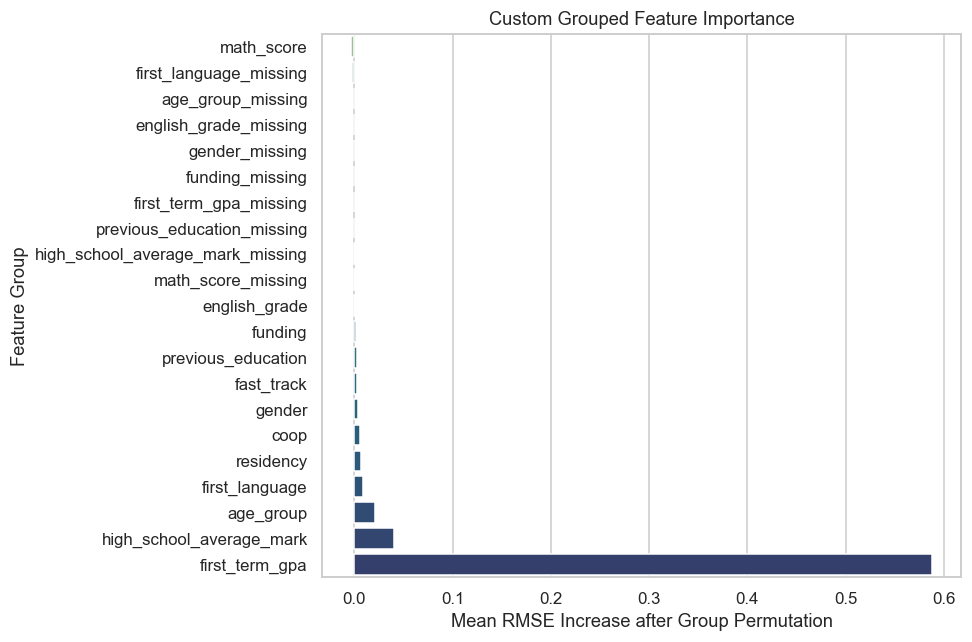

In [95]:
selected_model_name = validation_rank_df.iloc[0]['Model']
selected_model = experiment_models[selected_model_name]
print(f'Selected model for grouped feature importance: {selected_model_name}')

grouped_importance_df = compute_grouped_permutation_importance(
    selected_model,
    X_test,
    y_test,
    scaler,
    n_repeats=3,
    random_state=42,
)

display(grouped_importance_df)
plot_grouped_feature_importance(
    grouped_importance_df,
    title=f'{selected_model_name} Grouped Feature Importance',
)

### Experiment 5: Relay Modeling to Predict Third Term GPA

In [15]:
# check the nan values in first_term_gpa and second_term_gpa columns
clean_df["first_term_gpa"] = clean_df["first_term_gpa"].replace("?", np.nan).apply(pd.to_numeric, errors="coerce")
clean_df["second_term_gpa"] = clean_df["second_term_gpa"].replace("?", np.nan).apply(pd.to_numeric, errors="coerce")

print(f"Number of rows with nulls in first_term_gpa: {clean_df['first_term_gpa'].isna().sum()}")
print(f"Number of rows with nulls in second_term_gpa: {clean_df['second_term_gpa'].isna().sum()}")

clean_df = clean_df.dropna(subset=["second_term_gpa"])
clean_df = clean_df.dropna(subset=["first_term_gpa"])
print(f"Number of rows after dropping nulls in both first and second term GPA variables: {clean_df.shape[0]}")

Number of rows with nulls in first_term_gpa: 0
Number of rows with nulls in second_term_gpa: 0
Number of rows after dropping nulls in both first and second term GPA variables: 1277


In [16]:
clean_df.head()

,first_term_gpa,second_term_gpa,first_language,funding,school,fast_track,coop,residency,gender,previous_education,age_group,high_school_average_mark,math_score,english_grade,first_year_persistence
0,0.000000,0.000000,1,2.0,6.0,2.0,1.0,1.0,2.0,1,1,59,16,7,1.0
1,2.500000,2.000000,3,4.0,6.0,1.0,2.0,2.0,2.0,1,3,?,?,7,1.0
2,4.250000,3.923077,1,1.0,6.0,2.0,1.0,1.0,1.0,2,3,92,41,9,1.0
3,3.020833,2.321429,3,4.0,6.0,1.0,2.0,2.0,2.0,2,3,?,?,8,1.0
4,4.275000,4.326923,1,2.0,6.0,1.0,1.0,1.0,1.0,2,3,97,?,9,1.0


In [17]:
# Synthetic proxy for third-term GPA (relay model):
# Weighted progression from first- and second-term GPA,
# conditioned on first-year persistence (non-persistent students assigned 0)
clean_df["third_term_gpa_proxy"] = (
    0.6 * clean_df["second_term_gpa"] + 0.4 * clean_df["first_term_gpa"]
) * clean_df["first_year_persistence"]

# Feature and target separation
y_new = clean_df["third_term_gpa_proxy"] # third_term_gpa_proxy 
X_new = clean_df.drop(columns=["school","third_term_gpa_proxy"]) # Drop school - unique value

In [19]:
import joblib
# Load preprocessing pipeline
preprocessing_pipeline = joblib.load(
    project_path / "second_term_gpa_regression" / "models" / "best_model" / "preprocessing_pipeline.pkl"
)

# Load target scaler
target_scaler = joblib.load(
    project_path / "second_term_gpa_regression" / "models" / "best_model" / "target_scaler.pkl"
)

# Preprocess new dataset
X_new_processed = preprocessing_pipeline.transform(X_new.drop(columns=["second_term_gpa", "first_year_persistence"]))

# Load trained model without compiling
model = tf.keras.models.load_model(
    project_path / "second_term_gpa_regression" / "models" / "best_model" / "custom_model_bayesian.keras",
    compile=False
)

# Generate scaled predictions
y_pred_scaled = model.predict(X_new_processed).flatten()

# Convert predictions back to original GPA scale
y_pred = target_scaler.inverse_transform(
    y_pred_scaled.reshape(-1, 1)
).flatten()

# Compare actual vs predicted values
comparison_df = pd.DataFrame({
    "first_term_gpa": clean_df["first_term_gpa"].values,
    "actual_second_term_gpa": clean_df["second_term_gpa"].values,
    "predicted_second_term_gpa": y_pred
})

# Error analysis
comparison_df["absolute_error"] = (
    comparison_df["actual_second_term_gpa"] - comparison_df["predicted_second_term_gpa"]
).abs()

# Regression metrics
rmse = np.sqrt(
    np.mean(
        (comparison_df["actual_second_term_gpa"] - comparison_df["predicted_second_term_gpa"]) ** 2
    )
)

r2 = 1 - (
    np.sum(
        (comparison_df["actual_second_term_gpa"] - comparison_df["predicted_second_term_gpa"]) ** 2
    )
    /
    np.sum(
        (comparison_df["actual_second_term_gpa"] - comparison_df["actual_second_term_gpa"].mean()) ** 2
    )
)

# Print results
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

# Show first 15 rows
display(comparison_df.head(15))

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
RMSE: 0.6269
R²: 0.6912


,first_term_gpa,actual_second_term_gpa,predicted_second_term_gpa,absolute_error
0,0.000000,0.000000,0.057921,0.057921
1,2.500000,2.000000,2.389790,0.389790
2,4.250000,3.923077,4.129779,0.206702
3,3.020833,2.321429,2.910617,0.589188
4,4.275000,4.326923,4.156727,0.170196
5,4.357143,4.326087,4.181802,0.144285
6,2.210526,1.375000,1.728034,0.353034
7,2.045455,2.961538,1.797312,1.164226
8,4.285714,3.608696,4.166654,0.557958
9,2.863636,1.300000,2.369545,1.069545


In [20]:
X_new["predicted_second_term_gpa"] = y_pred
X_new.head()

,first_term_gpa,second_term_gpa,first_language,funding,fast_track,coop,residency,gender,previous_education,age_group,high_school_average_mark,math_score,english_grade,first_year_persistence,predicted_second_term_gpa
0,0.000000,0.000000,1,2.0,2.0,1.0,1.0,2.0,1,1,59,16,7,1.0,0.057921
1,2.500000,2.000000,3,4.0,1.0,2.0,2.0,2.0,1,3,?,?,7,1.0,2.389790
2,4.250000,3.923077,1,1.0,2.0,1.0,1.0,1.0,2,3,92,41,9,1.0,4.129779
3,3.020833,2.321429,3,4.0,1.0,2.0,2.0,2.0,2,3,?,?,8,1.0,2.910617
4,4.275000,4.326923,1,2.0,1.0,1.0,1.0,1.0,2,3,97,?,9,1.0,4.156727


In [21]:
#Drop original column
X_new = X_new.drop(columns=["second_term_gpa"])

# Rename predicted → official column
if "predicted_second_term_gpa" in X_new.columns:
    X_new = X_new.rename(
        columns={"predicted_second_term_gpa": "second_term_gpa"}
    )

X_new.head()

,first_term_gpa,first_language,funding,fast_track,coop,residency,gender,previous_education,age_group,high_school_average_mark,math_score,english_grade,first_year_persistence,second_term_gpa
0,0.000000,1,2.0,2.0,1.0,1.0,2.0,1,1,59,16,7,1.0,0.057921
1,2.500000,3,4.0,1.0,2.0,2.0,2.0,1,3,?,?,7,1.0,2.389790
2,4.250000,1,1.0,2.0,1.0,1.0,1.0,2,3,92,41,9,1.0,4.129779
3,3.020833,3,4.0,1.0,2.0,2.0,2.0,2,3,?,?,8,1.0,2.910617
4,4.275000,1,2.0,1.0,1.0,1.0,1.0,2,3,97,?,9,1.0,4.156727


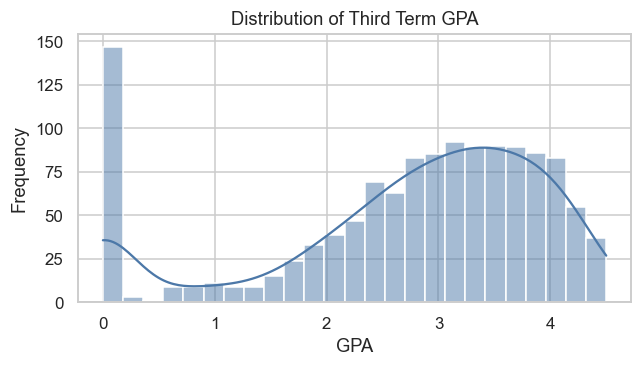

In [22]:
# check target variable distribution

plt.figure(figsize=(6,3.5))

sns.histplot(y_new, bins=25, kde=True, color="#4c78a8")
plt.title("Distribution of Third Term GPA")
plt.xlabel("GPA")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [23]:
# test-train split with stratification and train-only feature fitting
X_new_train_raw, X_new_test, y_new_train, y_new_test = train_test_split(
    X_new,
    y_new,
    test_size=0.2,
    random_state=42,
)

X_new_train, X_new_val, y_new_train, y_new_val = train_test_split(
    X_new_train_raw,
    y_new_train,
    test_size=0.125,  # 10% of total
    random_state=42,
)

print(f"X_new_train: {X_new_train.shape}, X_new_val: {X_new_val.shape}, X_new_test: {X_new_test.shape}")

X_new_train: (893, 14), X_new_val: (128, 14), X_new_test: (256, 14)


In [24]:
# check the final training dataset
display(X_new_train.head())

,first_term_gpa,first_language,funding,fast_track,coop,residency,gender,previous_education,age_group,high_school_average_mark,math_score,english_grade,first_year_persistence,second_term_gpa
78,3.521739,3,4.0,1.0,2.0,2.0,1.0,1,3,?,?,7,1.0,3.312875
353,2.250000,1,2.0,2.0,2.0,1.0,2.0,2,2,83,?,7,1.0,1.811014
1354,3.400000,3,4.0,1.0,2.0,2.0,1.0,2,4,?,?,8,1.0,3.325491
510,4.214286,1,2.0,2.0,1.0,1.0,2.0,2,4,73,49,9,1.0,3.617771
338,2.547619,1,2.0,2.0,1.0,1.0,2.0,1,2,78,27,9,0.0,2.108406


### Data Cleaning

In [25]:
# Data cleaning

from second_term_gpa_regression.utils.data_cleaner_proxy import DataCleaner

cleaner_2 = DataCleaner(numeric_imputer="bayesian")

X_new_train = cleaner_2.fit_transform(X_new_train)
X_new_val = cleaner_2.transform(X_new_val)
X_new_test = cleaner_2.transform(X_new_test)

# Target standardization
scaler_2 = MinMaxScaler()
y_new_train = scaler_2.fit_transform(y_new_train.values.reshape(-1, 1)).flatten()
y_new_val = scaler_2.transform(y_new_val.values.reshape(-1, 1)).flatten()
y_new_test = scaler_2.transform(y_new_test.values.reshape(-1, 1)).flatten()

In [26]:
import joblib

# save the preprocessing pipeline (DataCleaner object) to a file for later use in inference
joblib.dump(cleaner_2, project_path / "second_term_gpa_regression" / "models" / 'best_model' / "relay_third_term_preprocessing_pipeline.pkl")
joblib.dump(scaler_2, project_path / "second_term_gpa_regression" / "models" / 'best_model' / "relay_third_term_target_scaler.pkl")

# check the training after cleaning
display(X_new_train.head())

,first_term_gpa,fast_track,coop,residency,age_group,high_school_average_mark,math_score,english_grade,first_year_persistence,second_term_gpa,...,gender_1,gender_2,previous_education_0,previous_education_1,previous_education_2,previous_education_3,gpa_category_0,gpa_category_1,gpa_category_2,gpa_category_3
78,0.486143,1,0,0,3.0,0.476430,0.394267,7.0,1.0,0.537129,...,True,False,False,True,False,False,False,False,False,True
353,-0.763154,0,0,1,2.0,-0.043556,-0.747801,7.0,1.0,-0.995839,...,False,True,False,False,True,False,False,False,True,False
1354,0.366552,1,0,0,4.0,0.742809,0.619884,8.0,1.0,0.550006,...,True,False,False,False,True,False,False,False,False,True
510,1.166469,0,1,1,4.0,-0.980843,1.589309,9.0,1.0,0.848341,...,False,True,False,False,True,False,False,False,False,True
338,-0.470787,0,1,1,2.0,-0.512199,-0.776205,9.0,0.0,-0.692287,...,False,True,False,True,False,False,False,False,True,False


In [32]:
baseline_layers = [
    {'units': 516, 'activation': 'tanh', 'batch_norm': True, 'dropout': 0.1},
    {'units': 128, 'activation': 'elu', 'batch_norm': True, 'dropout': 0.2},
]

relay_baseline_model = build_dense_model(X_new_train.shape[1], baseline_layers)
relay_baseline_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 516)                 │          17,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 516)                 │           2,064 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 516)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │          66,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 86,425 (337.60 KB)

 Trainable params: 85,137 (332.57 KB)

 Non-trainable params: 1,288 (5.03 KB)

In [33]:
relay_baseline_model = compile_regression_model(relay_baseline_model, optimizer_name='sgd', learning_rate=0.0009)

relay_baseline_es, relay_baseline_mc = custom_callback(
    monitor='val_loss',
    mode='min',
    patience=20,
    filepath=project_path / 'second_term_gpa_regression' / 'models' / 'best_model' / 'relay_third_term_regression_ann_model.keras')

relay_history = relay_baseline_model.fit(
    X_new_train, y_new_train,
    validation_data=(X_new_val, y_new_val),
    epochs=200,
    batch_size=32,
    callbacks=[relay_baseline_es, relay_baseline_mc],
    verbose=1,
)

Epoch 1/200
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.8405 - mae: 1.0796 - r2: -21.2001 - rmse: 1.3540
Epoch 1: val_loss improved from None to 0.07207, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\best_model\relay_third_term_regression_ann_model.keras

Epoch 1: finished saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\best_model\relay_third_term_regression_ann_model.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 1.4524 - mae: 0.9306 - r2: -16.6319 - rmse: 1.2052 - val_loss: 0.0721 - val_mae: 0.2349 - val_r2: 0.0856 - val_rmse: 0.2685
Epoch 2/200
25/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4820 - mae: 0.5238 - r2: -4.5007 - rmse: 0.6937
Epoch 2: val_loss improved from 0.07207 to 0.04596, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predic

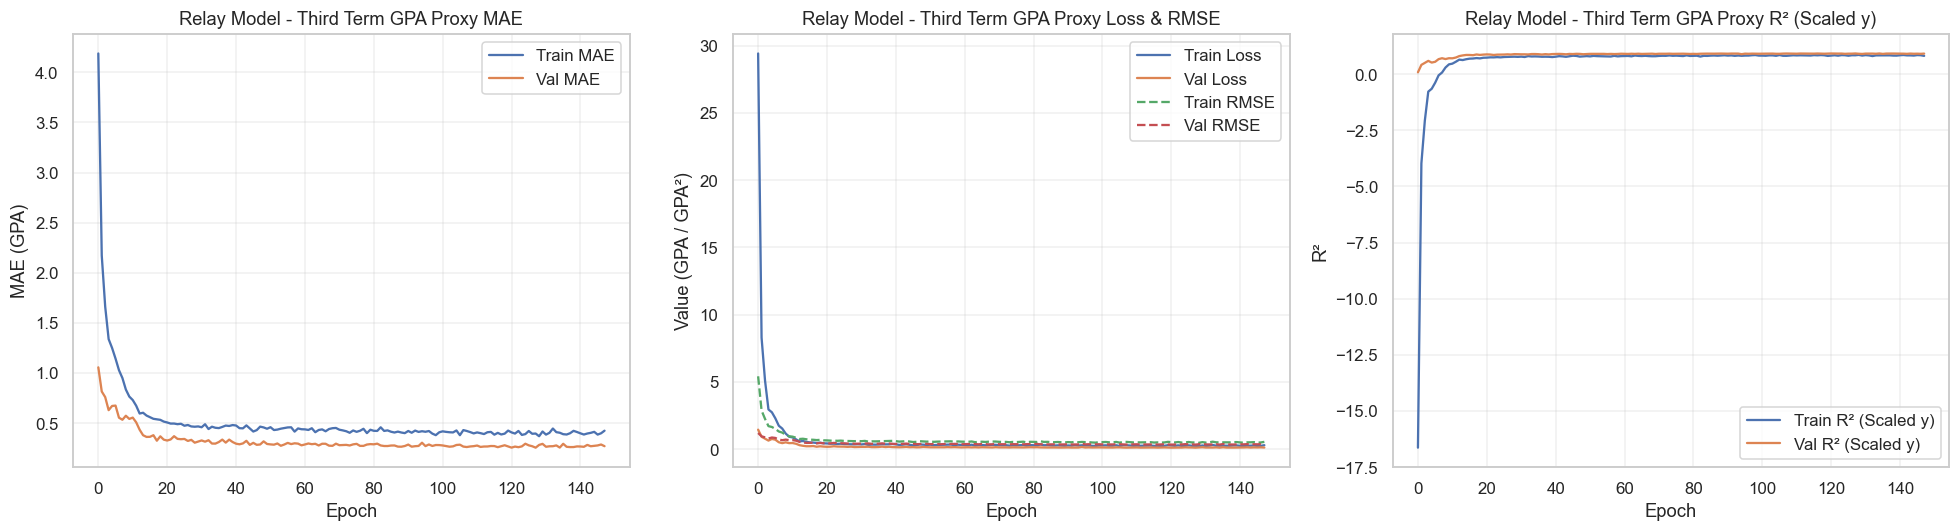


Best Epoch: 128
----------------------------------------
MAE (GPA)   -> Train: 0.3969 | Val: 0.2560
RMSE (GPA)  -> Train: 0.5108 | Val: 0.3480
Loss (GPA²) -> Train: 0.2609 | Val: 0.1211
R² (Scaled y) -> Train: 0.8436 | Val: 0.9241


In [34]:
plot_regression_history(relay_history, title_prefix='Relay Model - Third Term GPA Proxy')

In [35]:
relay_val_metrics, relay_val_df = evaluate_model_original_scale(
    relay_baseline_model, X_new_val, y_new_val, scaler, split_name='Relay Validation'
)
relay_test_metrics, relay_test_df = evaluate_model_original_scale(
    relay_baseline_model, X_new_test, y_new_test, scaler, split_name='Relay Test'
)

relay_summary_df = pd.DataFrame([relay_val_metrics, relay_test_metrics]).set_index('split')
display(format_metrics_display(relay_summary_df))
display(relay_test_df.head(15))


Relay Validation RMSE: 0.3480
Relay Validation MSE:  0.1211
Relay Validation MAE:              0.2560
Relay Validation R² (Original GPA): 0.9241
Relay Validation R² (Scaled y):     0.9241
Relay Test RMSE: 0.3458
Relay Test MSE:  0.1196
Relay Test MAE:              0.2561
Relay Test R² (Original GPA): 0.9176
Relay Test R² (Scaled y):     0.9176


,RMSE (GPA),MSE (GPA²),MAE (GPA),R² (Original GPA),R² (Scaled y)
split,,,,,
Relay Validation,0.348041,0.121132,0.256013,0.924106,0.924106
Relay Test,0.345779,0.119563,0.256132,0.917617,0.917617


,Actual GPA,Predicted GPA,Residual,Absolute Error,Squared Error
0,0.932053,2.388174,-1.456122,1.456122,2.120290
1,0.000000,1.172354,-1.172354,1.172354,1.374414
2,0.542784,1.663223,-1.120439,1.120439,1.255385
3,0.218512,1.316722,-1.098211,1.098211,1.206067
4,1.175074,2.247233,-1.072159,1.072159,1.149525
5,0.794072,1.817505,-1.023433,1.023433,1.047415
6,0.430781,1.423290,-0.992509,0.992509,0.985075
7,0.000000,0.853348,-0.853348,0.853348,0.728203
8,1.641875,2.468475,-0.826601,0.826601,0.683269
9,2.286334,3.033919,-0.747586,0.747586,0.558884


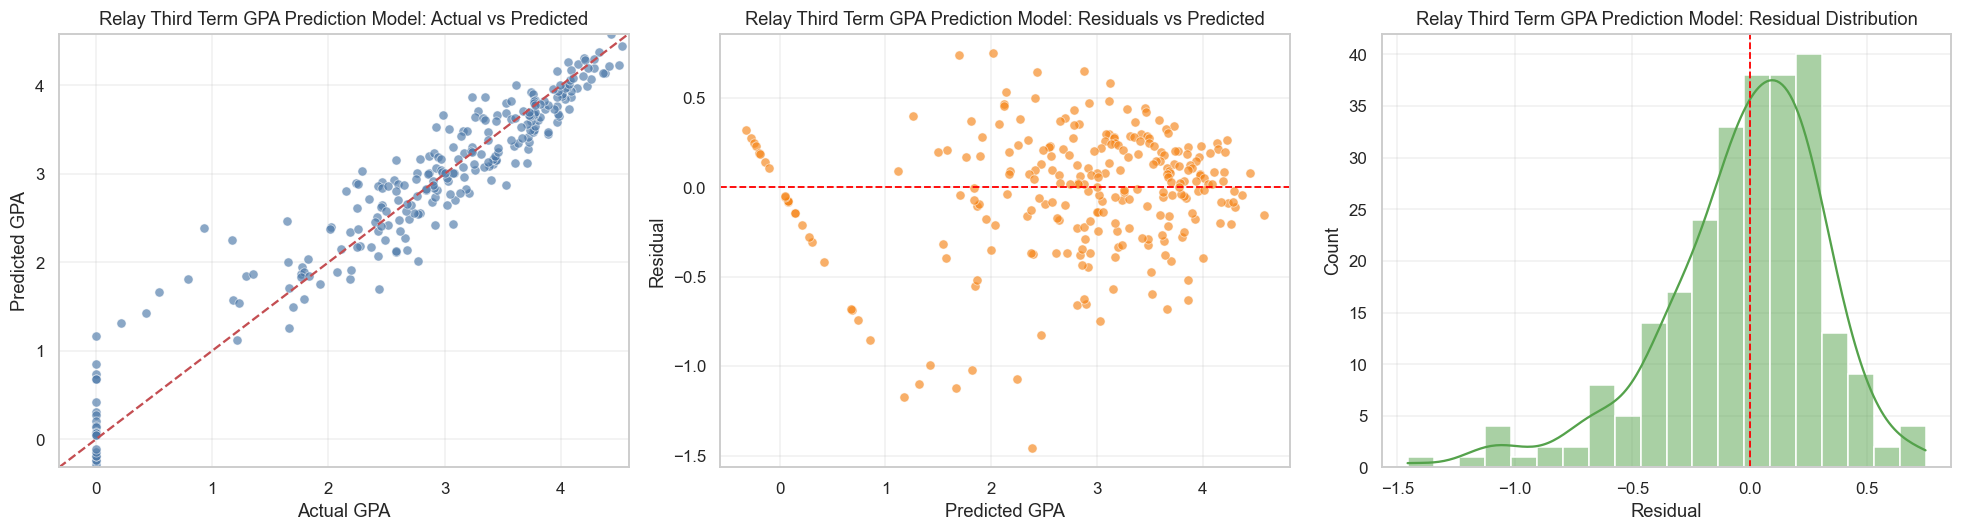

In [37]:
plot_prediction_diagnostics(relay_test_df, title_prefix='Relay Third Term GPA Prediction Model')

In [ ]:
#load the saved relay model from best_model directory / relay_third_term_regression_ann_model.keras
# loaded_relay_model = tf.keras.models.load_model(project_path / 'second_term_gpa_regression' / 'models' / 'best_model' / 'relay_third_term_regression_ann_model.keras',custom_objects={"RMSEMetric": RMSEMetric, "R2Metric": R2Metric})

,Feature Group,RMSE Increase (Mean),RMSE Increase (Std),R² Drop (Mean),Grouped Columns
0,first_year_persistence,0.654455,0.021031,0.611939,first_year_persistence
1,second_term_gpa,0.382514,0.000707,0.285070,second_term_gpa
2,first_term_gpa,0.291664,0.006092,0.198943,first_term_gpa
3,age_group,0.010309,0.010208,0.005084,age_group
4,high_school_average_mark,0.009010,0.001178,0.004373,high_school_average_mark
5,gpa_category,0.008266,0.003048,0.004013,"gpa_category_0, gpa_category_1, gpa_category_2..."
6,first_language,0.006845,0.002097,0.003314,"first_language_0, first_language_1, first_lang..."
7,english_grade,0.005745,0.002709,0.002780,english_grade
8,fast_track,0.005325,0.001746,0.002572,fast_track
9,residency,0.004986,0.000549,0.002406,residency


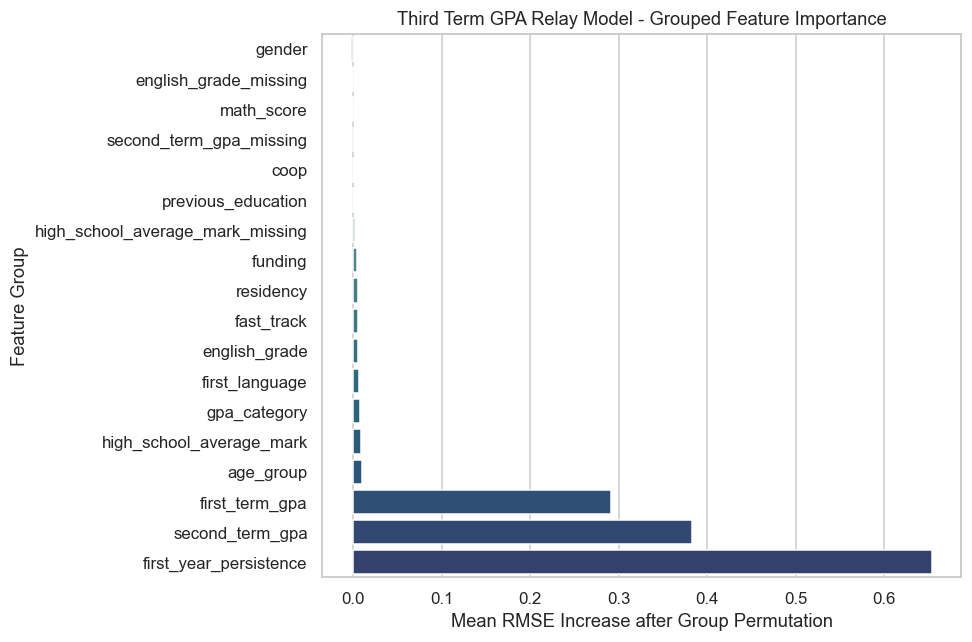

In [38]:
proxy_grouped_importance_df = compute_proxy_grouped_permutation_importance(
    relay_baseline_model,
    X_new_test,
    y_new_test,
    scaler_2,
    n_repeats=3,
    random_state=42,
)

display(proxy_grouped_importance_df)
plot_grouped_feature_importance(
    proxy_grouped_importance_df,
    title='Third Term GPA Relay Model - Grouped Feature Importance',
)